# Week 46

### **1. AUC (Area Under the Curve)**

* **What it measures:**
  How well the model can distinguish between positive and negative cases overall.
* **Range:** 0.5 (random guessing) → 1.0 (perfect separation).
* **Interpretation:**

  * The higher the AUC, the better the model is at ranking positive samples higher than negatives.
  * For example, in link prediction, a high AUC means the model gives higher probabilities to true links than to false ones.

---

### **2. Precision**

* **What it measures:**
  Out of all the predictions the model said were positive, how many were actually positive?
* **Formula:**
  `Precision = True Positives / (True Positives + False Positives)`
* **Interpretation:**

  * High Precision means *few false alarms* (the model doesn’t label too many wrong links as existing).
  * Think of it as **“accuracy among positives.”**

---

### **3. Recall**

* **What it measures:**
  Out of all the actual positive cases, how many did the model correctly identify?
* **Formula:**
  `Recall = True Positives / (True Positives + False Negatives)`
* **Interpretation:**

  * High Recall means *few misses* (the model finds most of the true links).
  * Think of it as **“coverage of the positives.”**

---

### **4. F1 Score**

* **What it measures:**
  The **balance** between Precision and Recall.
* **Formula:**
  `F1 = 2 × (Precision × Recall) / (Precision + Recall)`
* **Interpretation:**

  * A high F1 means the model performs well both in detecting true positives and in avoiding false positives.
  * It’s especially useful when the dataset is **imbalanced** (e.g., far more negative links than positive ones).

---

### **In my food web link-prediction context:**

* **AUC** tells us the *overall ranking quality* of predicted links.
* **Precision** tells us *how reliable* our predicted links are.
* **Recall** tells us *how complete* our predictions are.
* **F1 Score** gives us a *single balanced measure* of both reliability and completeness.

[INFO] Limiting to first 5 CSV files for plotting.


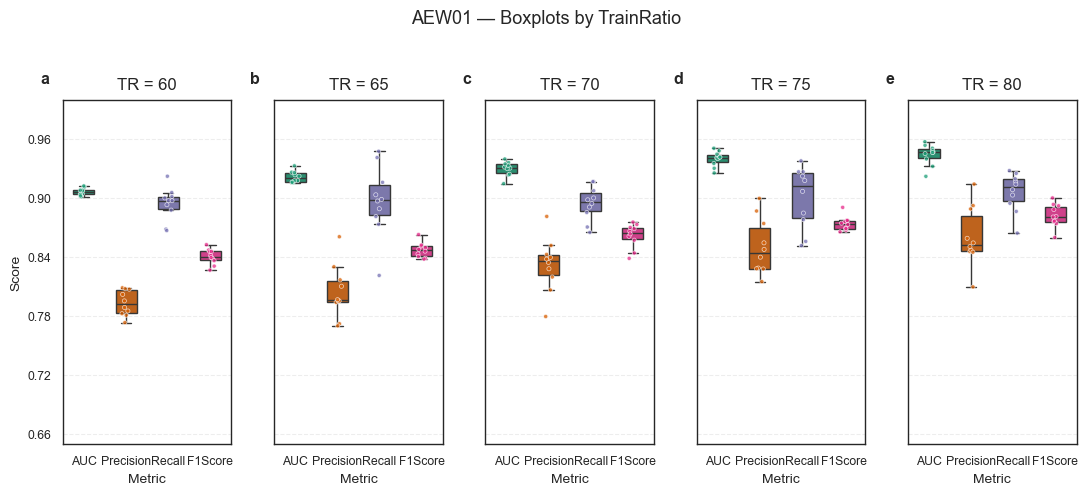

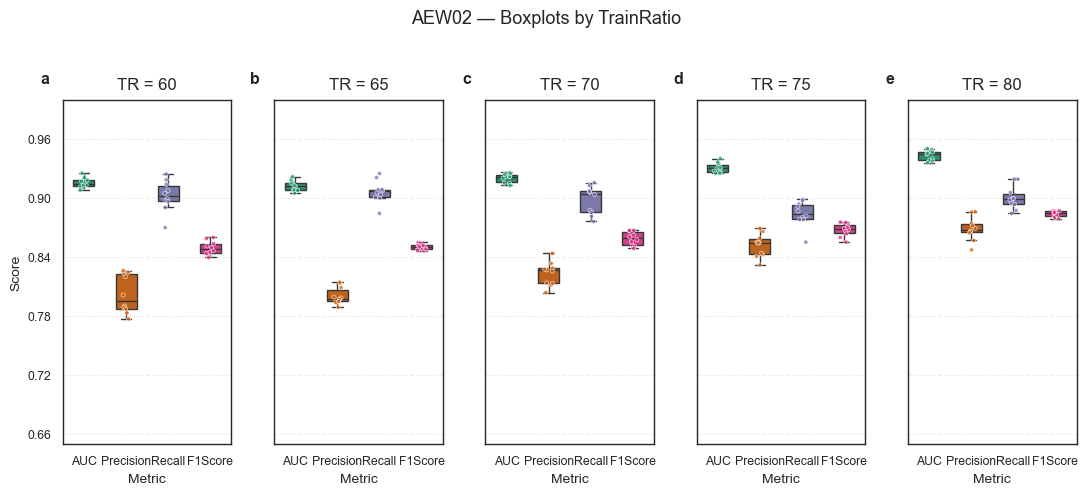

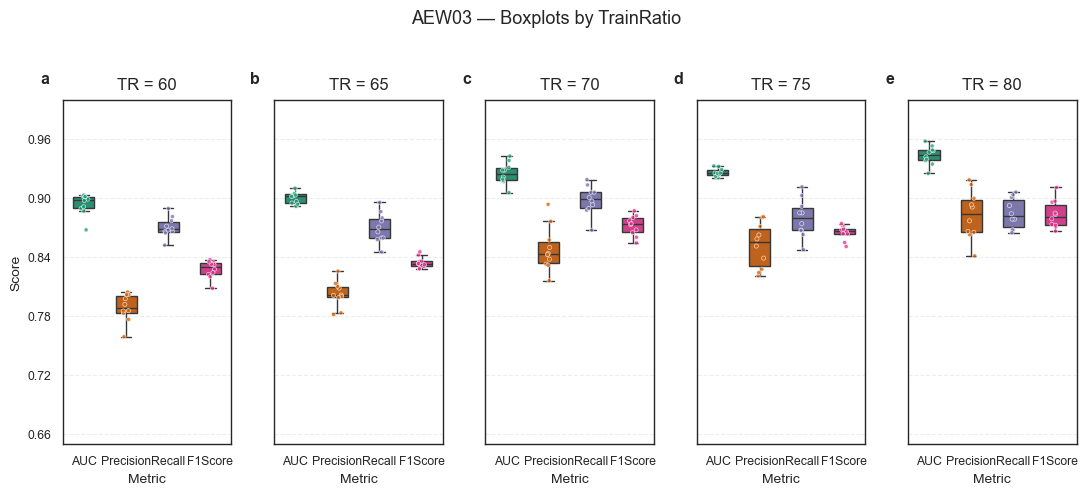

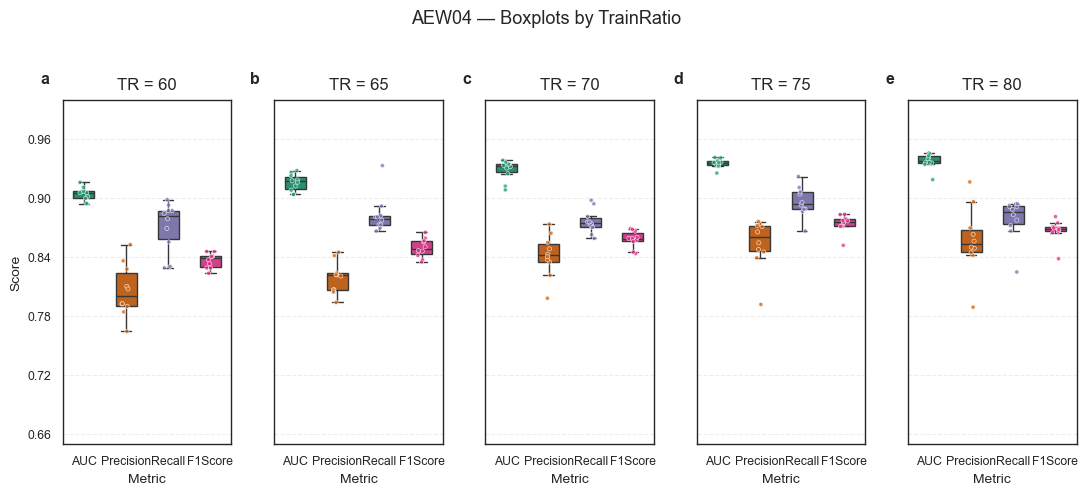

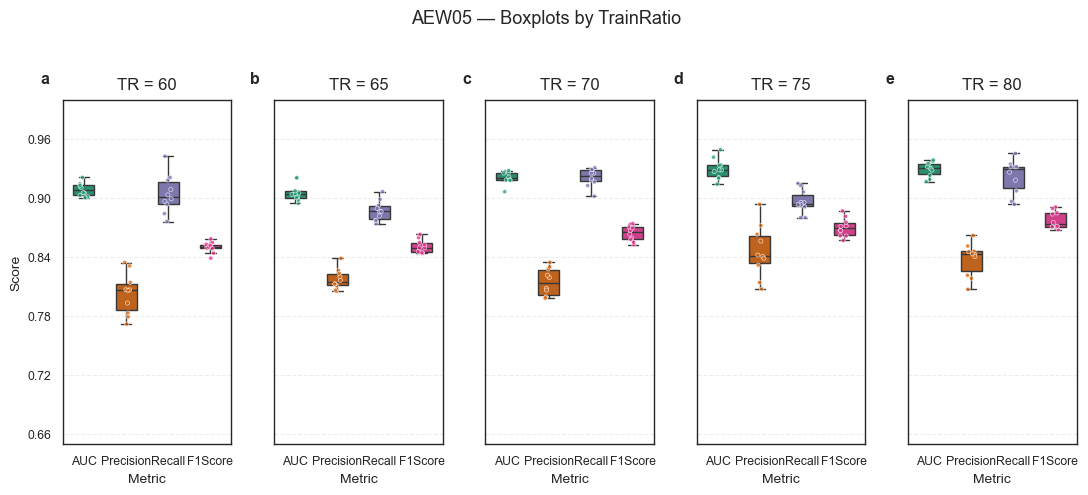

In [1]:
import os, glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Configuration ===
RESULTS_DIR = "../../src/matlab/data/result_sweep_train_ratios_290/prediction_scores_logs/"
SINGLE_FILE = None  # disable when using directory
METRICS = ["AUC", "Precision", "Recall", "F1Score"]
MAX_PLOTS = 5   # ⬅️ limit number of foodweb plots (set None for all)

# === Utility functions ===
def derive_foodweb_from_filename(path: str) -> str:
    base = os.path.basename(path)
    name, _ = os.path.splitext(base)
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    name = "_".join([p for p in name.split("_") if p])
    return name

def load_results(results_dir=None, single_file=None) -> pd.DataFrame:
    paths = []
    if results_dir and os.path.isdir(results_dir):
        paths = sorted(glob.glob(os.path.join(results_dir, "*.csv")))
        if MAX_PLOTS is not None:
            paths = paths[:MAX_PLOTS]
            print(f"[INFO] Limiting to first {len(paths)} CSV files for plotting.")
    if single_file and os.path.isfile(single_file):
        paths.append(single_file)
    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    frames = []
    for p in paths:
        try:
            df = pd.read_csv(p)
        except Exception as e:
            print(f"Skipping {p}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        # Normalize to upper for metrics, keep original for TrainRatio detection
        upper_map = {c: c.upper() for c in df.columns}
        df = df.rename(columns=upper_map)
        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(p)
        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")
    return pd.concat(frames, ignore_index=True)

# === Load (ALL train ratios kept) and preprocess ===
df = load_results(results_dir=RESULTS_DIR, single_file=SINGLE_FILE)

# Normalize TrainRatio into a single 'TRAINRATIO' column (as percentages)
tr_candidates = [c for c in df.columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
if not tr_candidates:
    raise ValueError("No TrainRatio column found.")
tr_col = tr_candidates[0]
df["TRAINRATIO"] = pd.to_numeric(df[tr_col], errors="coerce")
if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)

# === Auto-detect & sort TrainRatios present in the data ===
TRAIN_RATIOS_DETECTED = sorted(df["TRAINRATIO"].dropna().unique().astype(int).tolist())
if not TRAIN_RATIOS_DETECTED:
    raise ValueError("No valid TrainRatio values were detected.")

# === Prepare long form with TRAINRATIO kept ===
present = [m for m in METRICS if m.upper() in df.columns]
if not present:
    raise ValueError("None of the requested METRICS were found.")
long_frames = []
for m in present:
    mu = m.upper()
    tmp = df[["FOODWEB", "TRAINRATIO", mu]].rename(columns={mu: "Value"})
    tmp["Metric"] = m
    long_frames.append(tmp)
df_long = pd.concat(long_frames, ignore_index=True)

# Custom palette (per metric, consistent across subplots)
metric_colors = {
    "AUC": "#1b9e77", "Precision": "#d95f02",
    "Recall": "#7570b3", "F1Score": "#e7298a",
}
palette = {k: metric_colors.get(k, "#5aa9e6") for k in df_long["Metric"].unique()}
order = list(present)
pal_list = [palette[m] for m in order]

# === Plot: 1 row per foodweb, columns = all detected TrainRatios ===
unique_foodwebs = df_long["FOODWEB"].unique()
if MAX_PLOTS is not None:
    unique_foodwebs = unique_foodwebs[:MAX_PLOTS]

# panel letters (a, b, c, d, ...) sized to number of columns
letters_all = [chr(ord('a') + i) for i in range(len(TRAIN_RATIOS_DETECTED))]

for fw in unique_foodwebs:
    sub_fw = df_long[df_long["FOODWEB"] == fw].copy()
    n_cols = max(1, len(TRAIN_RATIOS_DETECTED))
    fig_w = max(7, 2.2 * n_cols)  # scale width with number of columns
    fig, axes = plt.subplots(1, n_cols, figsize=(fig_w, 5), sharey=True)

    # axes to list for consistent indexing
    if n_cols == 1:
        axes = [axes]

    for j, tr in enumerate(TRAIN_RATIOS_DETECTED):
        ax = axes[j]
        sub_tr = sub_fw[sub_fw["TRAINRATIO"] == tr]

        if sub_tr.empty:
            ax.set_axis_off()
            ax.text(0.5, 0.5, f"No data\nTR={tr}", ha="center", va="center", fontsize=10)
            continue

        # Boxplot with Metric on x (adds visual space between boxes)
        sns.boxplot(
            data=sub_tr, x="Metric", y="Value",
            order=order, palette=pal_list,
            hue="Metric",           # consistent colors per metric
            width=0.5, showfliers=False,
            ax=ax
        )
        # Overlay stripplot (same color scheme)
        sns.stripplot(
            data=sub_tr, x="Metric", y="Value",
            order=order, palette=pal_list,
            hue="Metric",
            dodge=False, jitter=0.10,
            size=3.0, alpha=0.75,
            edgecolor="white", linewidth=0.5,
            ax=ax
        )

        # Remove duplicate legends that may appear from hue usage
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        # Bold panel letters aligned with columns
        if j < len(letters_all):
            ax.annotate(
                letters_all[j],
                xy=(0, 1), xycoords="axes fraction",
                xytext=(-10, 10), textcoords="offset points",
                ha="right", va="bottom",
                fontsize="large", fontweight="bold",
                annotation_clip=False
            )

        ax.set_title(f"TR = {tr}", fontsize=12, pad=8)
        ax.set_xlabel("Metric", fontsize=10)
        if j == 0:
            ax.set_ylabel("Score", fontsize=10)
        else:
            ax.set_ylabel("")

        ax.set_ylim(0.65, 1.0)
        ax.yaxis.set_major_locator(plt.MaxNLocator(6))
        ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    fig.suptitle(f"{fw} — Boxplots by TrainRatio", y=0.98, fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

[INFO] Loading up to 5 CSV files from directory (5 found).


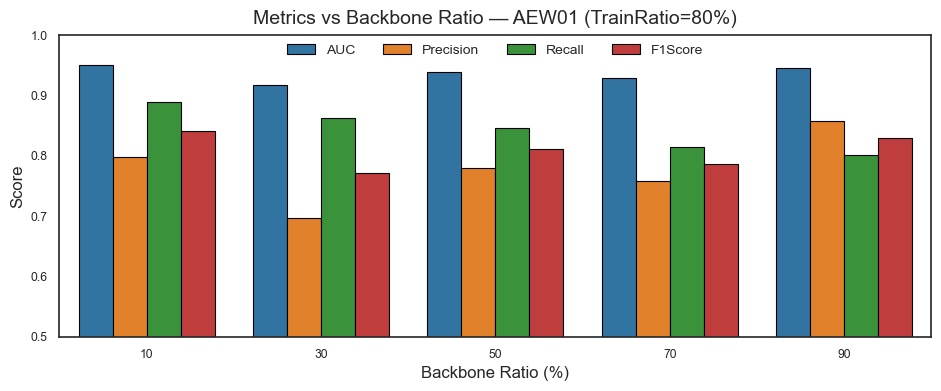

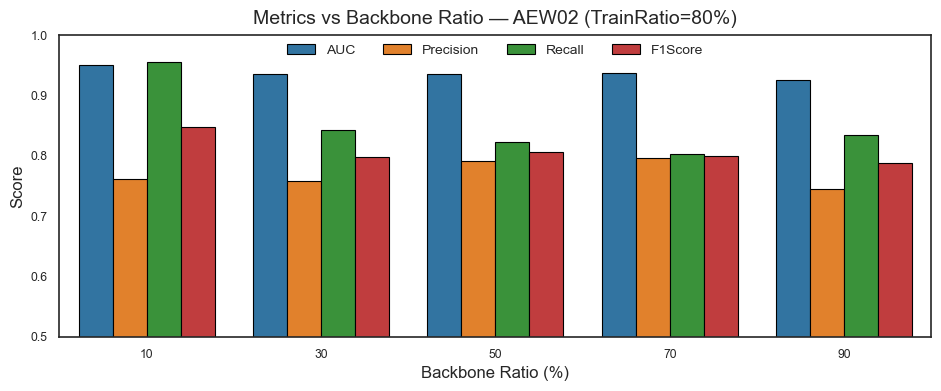

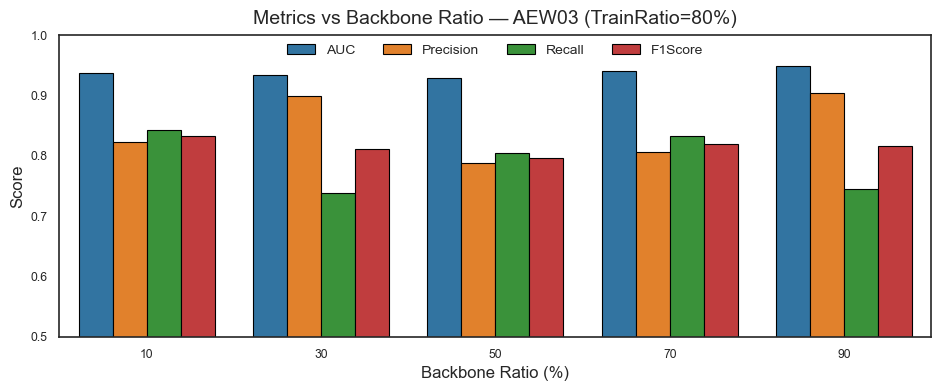

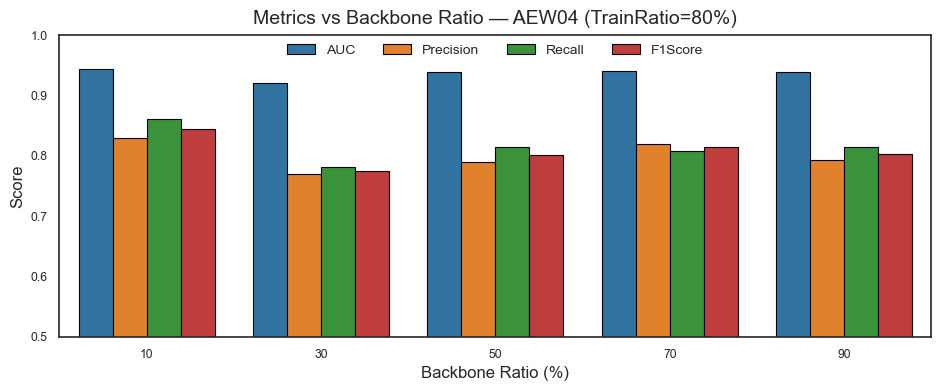

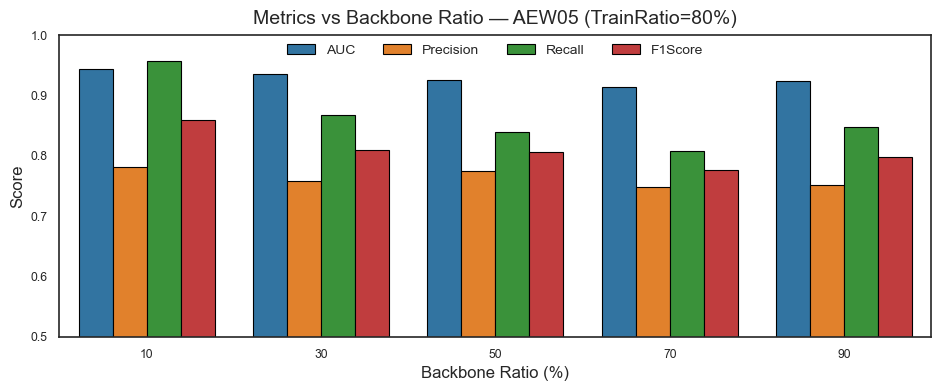

In [1]:
# %% Imports & setup
import os, glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Estilo general ===
sns.set_context("paper")
sns.set_style("white")

# === Config ===
RESULTS_DIR = "../../src/matlab/data/result_sweep_trainRatio_60-80_backboneRatio_10-90/prediction_scores_logs/"
SINGLE_FILE = None
TARGET_TRAINRATIO = 80   # <-- filtra solo este TrainRatio
METRICS = ["AUC", "Precision", "Recall", "F1Score"]
LIMIT_FILES = 5  # ⬅️ limita número de archivos cargados

# === Helpers ===
def derive_foodweb_from_filename(path: str) -> str:
    base = os.path.basename(path)
    name, _ = os.path.splitext(base)
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    name = "_".join([p for p in name.split("_") if p])
    return name

def load_results(results_dir=None, single_file=None, limit_files=5, target_trainratio=None) -> pd.DataFrame:
    """Carga uno o varios CSVs, filtra TrainRatio si está definido, y limita a los primeros `limit_files`."""
    paths = []
    if results_dir and os.path.isdir(results_dir):
        all_paths = sorted(glob.glob(os.path.join(results_dir, "*.csv")))
        if not all_paths:
            raise FileNotFoundError(f"No CSV files found in {results_dir}.")
        paths = all_paths[:limit_files]
        print(f"[INFO] Loading up to {limit_files} CSV files from directory ({len(paths)} found).")
    elif single_file and os.path.isfile(single_file):
        paths = [single_file]
        print("[INFO] Loading single CSV file.")
    else:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    frames = []
    for p in paths:
        try:
            df = pd.read_csv(p)
        except Exception as e:
            print(f"Skipping {p}: {e}")
            continue

        # Normaliza nombres
        df.columns = [c.strip() for c in df.columns]
        up = {c: c.upper() for c in df.columns}
        df = df.rename(columns=up)

        # FOODWEB
        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(p)

        # --- Filtrado por TrainRatio (si está disponible) ---
        train_col = next((c for c in ["TRAINRATIO", "TRAIN_RATIO"] if c in df.columns), None)
        if train_col is not None and target_trainratio is not None:
            df["TRAINRATIO_PCT"] = (
                (df[train_col] * 100).round().astype(int)
                if df[train_col].between(0, 1).all()
                else df[train_col].round().astype(int)
            )
            before_rows = len(df)
            df = df[df["TRAINRATIO_PCT"] == target_trainratio].copy()
            # print(f"[INFO] {os.path.basename(p)} → filtered {before_rows}→{len(df)} rows for TrainRatio={target_trainratio}")
            if df.empty:
                continue

        # BackboneRatio robusto
        bb_candidates = [
            "BACKBONERATIO", "BACKBONE_RATIO", "BACKBONE",
            "BKRATIO", "BACKBONEPCT", "BACKBONE_PERCENT", "BACKBONE_PERCENTAGE"
        ]
        bb_col = next((c for c in bb_candidates if c in df.columns), None)
        if bb_col is None:
            for m in ["BackboneRatio", "Backbone", "Backbone_Pct", "Backbone_Percent"]:
                if m in (c for c in df.columns):
                    df = df.rename(columns={m: "BACKBONERATIO"})
                    bb_col = "BACKBONERATIO"
                    break
        else:
            if bb_col != "BACKBONERATIO":
                df = df.rename(columns={bb_col: "BACKBONERATIO"})
                bb_col = "BACKBONERATIO"
        if bb_col is None:
            print(f"Skipping {p}: missing 'BackboneRatio' column.")
            continue

        # Métricas presentes
        present_metrics = [m for m in METRICS if (m.upper() in df.columns or m in df.columns)]
        rename_map = {m.upper(): m for m in present_metrics if m.upper() in df.columns}
        df = df.rename(columns=rename_map)

        cols_to_keep = ["FOODWEB", "BACKBONERATIO"] + [m for m in METRICS if m in df.columns]
        df = df[cols_to_keep].copy()

        # Normaliza BackboneRatio a porcentaje entero
        if df["BACKBONERATIO"].dropna().between(0, 1).all():
            df["BACKBONE_PCT"] = (df["BACKBONERATIO"] * 100).round().astype(int)
        else:
            df["BACKBONE_PCT"] = df["BACKBONERATIO"].round().astype(int)

        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded after filtering.")
    return pd.concat(frames, ignore_index=True)

# %% Load results (solo TrainRatio=80)
df = load_results(results_dir=RESULTS_DIR, single_file=SINGLE_FILE, limit_files=LIMIT_FILES, target_trainratio=TARGET_TRAINRATIO)

# === Plot loop: 1 gráfico por FOODWEB ===
unique_foodwebs = df["FOODWEB"].unique().tolist()
for foodweb in unique_foodwebs:
    subset = df[df["FOODWEB"] == foodweb].copy()
    if subset.empty:
        continue

    # Detecta automáticamente 10→90
    uniq = sorted(subset["BACKBONE_PCT"].dropna().unique().astype(int).tolist())
    ten_to_ninety = [r for r in range(10, 100, 10)]
    order = [r for r in ten_to_ninety if r in uniq] or uniq

    # Categórico
    subset["Backbone"] = pd.Categorical(
        subset["BACKBONE_PCT"].astype(int).astype(str),
        categories=[str(o) for o in order],
        ordered=True
    )

    # Formato largo
    present_metrics = [m for m in METRICS if m in subset.columns]
    df_long = subset.melt(
        id_vars=["FOODWEB", "BACKBONE_PCT", "Backbone"],
        value_vars=present_metrics,
        var_name="Metric", value_name="Score"
    ).dropna(subset=["Score"])

    # Media por Backbone y Métrica
    plot_df = (
        df_long.groupby(["Backbone", "Metric"], as_index=False, observed=True)["Score"]
        .mean()
    )

    # Límites Y
    vals = plot_df["Score"].astype(float)
    if not vals.empty and vals.between(0, 1).all():
        y_min, y_max = 0.5, 1.0
    else:
        y_min, y_max = 0.0, float(vals.max() * 1.1) if not vals.empty else 1.0

    # === Plot ===
    plt.figure(figsize=(9.5, 4))

    # NEW: use only as many tab10 colors as needed for the present metrics
    tab10_subset = sns.color_palette("tab10", n_colors=len(present_metrics))
    metric_palette = {m: tab10_subset[i] for i, m in enumerate(present_metrics)}  # stable mapping

    ax = sns.barplot(
        data=plot_df,
        x="Backbone", y="Score",
        hue="Metric",
        order=[str(o) for o in order],
        hue_order=present_metrics,
        estimator=np.mean, errorbar=None,
        palette=metric_palette,     # ← use subset/dict (no warning)
        width=0.78,
        edgecolor="black",
        linewidth=0.8
    )

    # Fallback (some versions ignore edgecolor in barplot)
    for p in ax.patches:
        p.set_edgecolor("black")
        p.set_linewidth(0.8)

    ax.grid(False)
    for side in ["top", "right", "left", "bottom"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.2)

    ax.set_title(f"Metrics vs Backbone Ratio — {foodweb} (TrainRatio={TARGET_TRAINRATIO}%)", pad=8, fontsize=14)
    ax.set_xlabel("Backbone Ratio (%)", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_ylim(y_min, y_max)
    ax.tick_params(axis="both", which="both", length=5, width=1.0)

    ax.legend(
        title=None,
        frameon=False,
        ncol=len(present_metrics),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.08),
        borderaxespad=2,
        fontsize=10
    )

    plt.tight_layout()
    plt.show()

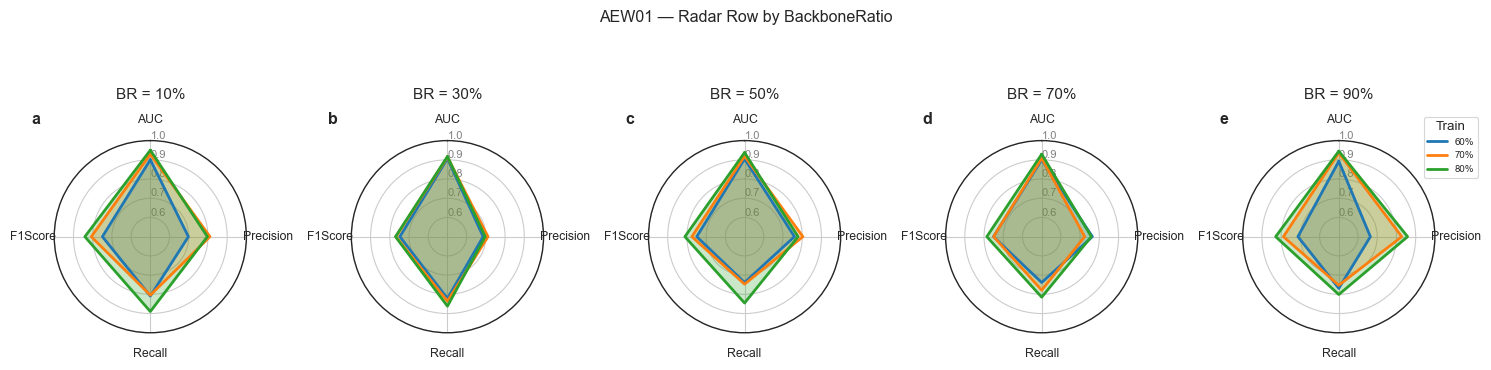

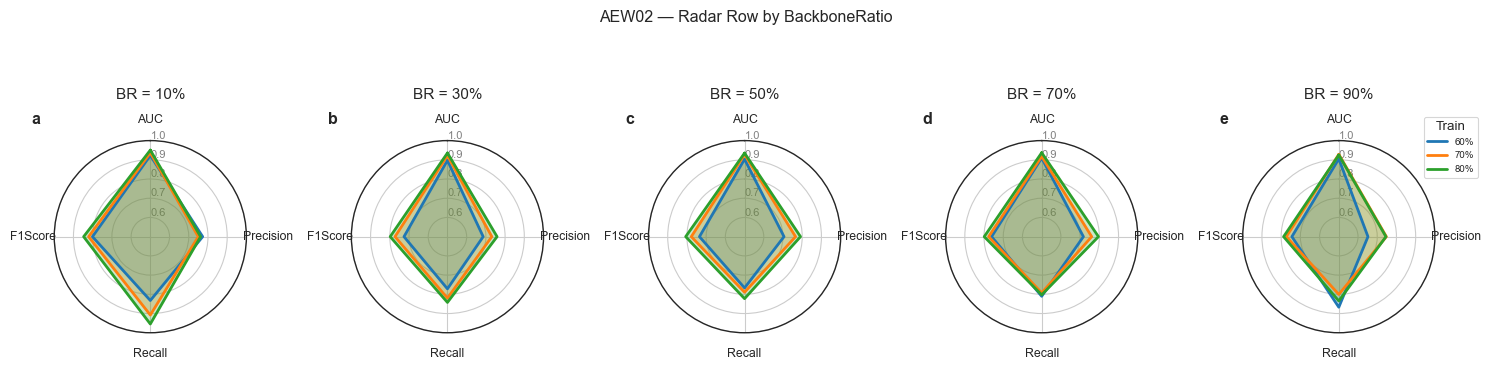

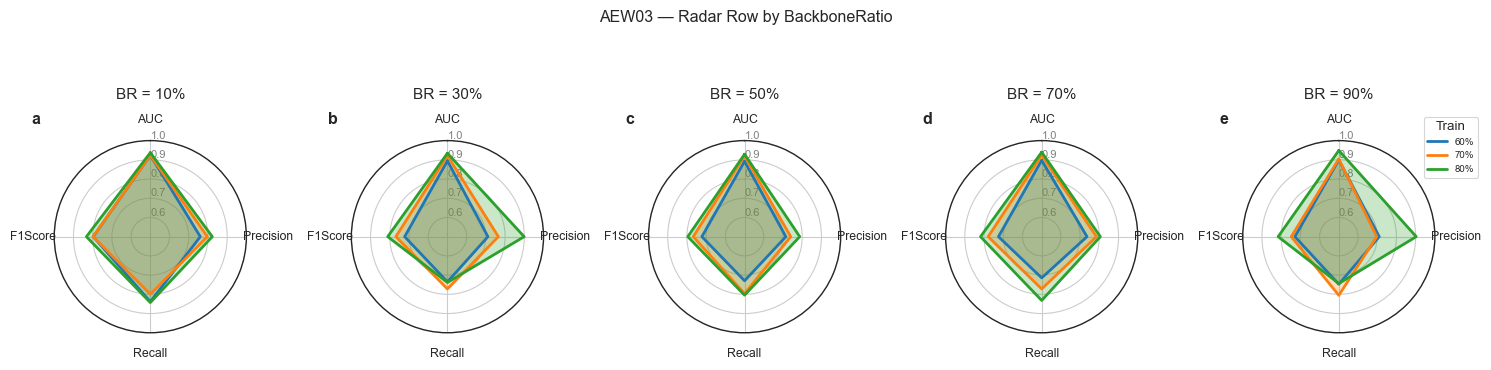

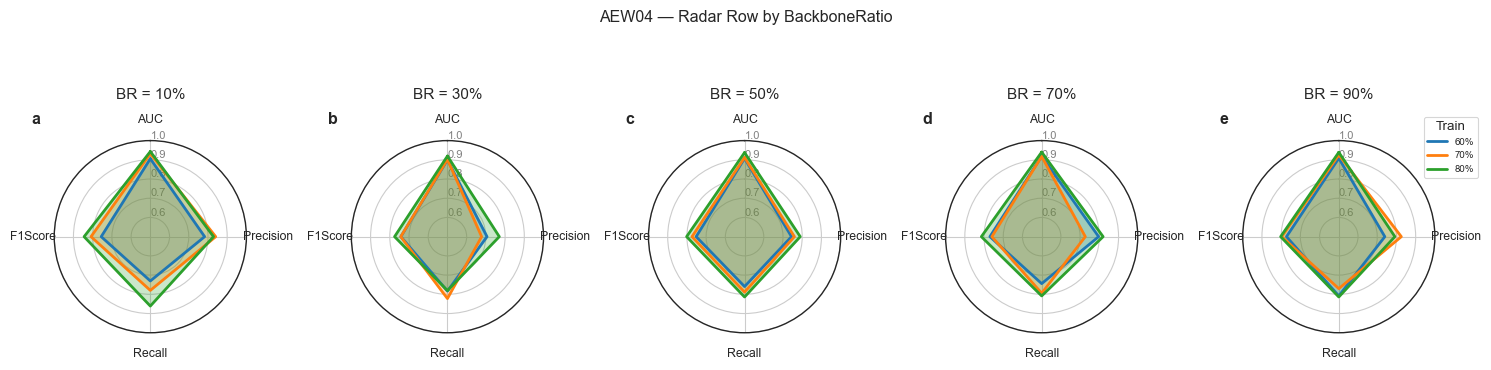

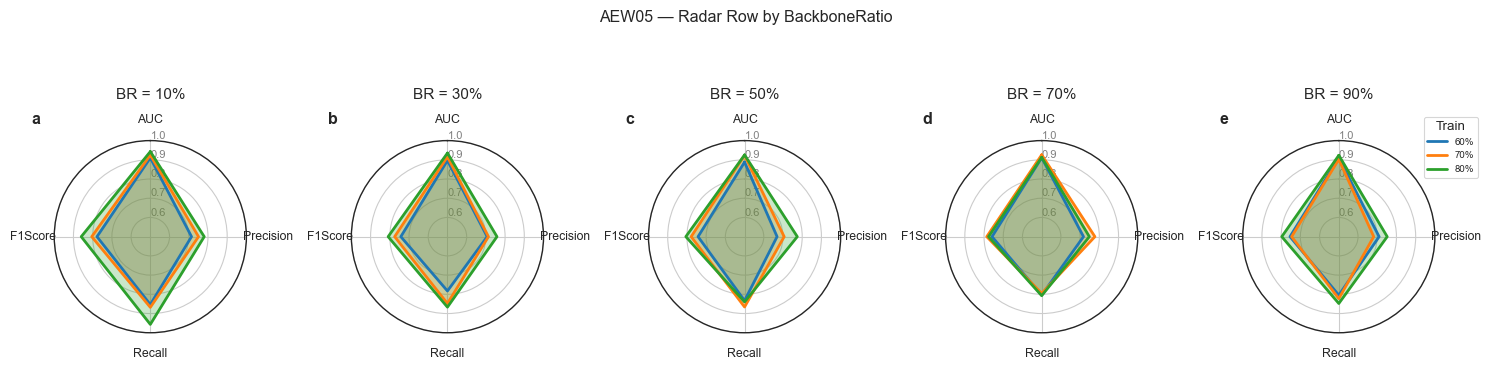

[Info] Reached display limit (5). Skipping remaining files.
Done. Displayed 5 radar rows (limit = 5).


In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import seaborn as sns  # ← added

# ← added
sns.set_context("paper")
sns.set_style("white")

# ========= Config =========
INPUT_DIR = "../../src/matlab/data/result_sweep_trainRatio_60-80_backboneRatio_10-90/prediction_scores_logs"
GLOB_PATTERNS = [
    "*_results_random.csv",
    "*_results_*.csv",
    "*_result_*.csv"
]
metrics = ["AUC", "Precision", "Recall", "F1Score"]
train_ratios = [60, 70, 80]
colors = {60: "C0", 70: "C1", 80: "C2"}
alpha_fill = 0.25
MAX_SHOW = 5  # show at most 5 figures

# NEW: Backbone ratios to show as 5 columns
backbone_targets = [10, 30, 50, 70, 90]

# ========= Helpers =========
def normalize_train_ratio(x):
    """Return ratio as percentage in [0..100] (accept 0.8 or 80)."""
    try:
        x = float(x)
    except Exception:
        return np.nan
    return round(x if x > 1 else x * 100, 0)

def normalize_backbone_ratio(x):
    """Return backbone ratio as percentage in [0..100] (accept 0.9 or 90)."""
    try:
        x = float(x)
    except Exception:
        return np.nan
    return round(x if x > 1 else x * 100, 0)

def compute_angles(labels):
    """Angles for radar chart and closed loop."""
    N = len(labels)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    return angles

def pick_col(cols, candidates):
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    raise KeyError(f"None of {candidates} found among: {list(cols)}")

def plot_radar_row(df, title):
    """Draw a 1x5 row of radars, one per BackboneRatio in backbone_targets.
       Each radar shows series for the configured train_ratios.
    """
    # --- Find columns (robust names) ---
    try:
        tr_col = pick_col(df.columns, ["TrainRatio","Train_Ratio","train_ratio"])
    except KeyError:
        print(f"[Warn] Missing TrainRatio column in '{title}', skipping.")
        return

    try:
        bb_col = pick_col(df.columns, ["BackboneRatio","Backbone_Ratio","Backbone","b_ratio"])
    except KeyError:
        print(f"[Warn] Missing BackboneRatio column in '{title}', skipping.")
        return

    # Normalize TR and BR to integer percentages
    df = df.copy()
    df["_TrainRatioPct"] = df[tr_col].apply(normalize_train_ratio)
    df["_BackbonePct"]   = df[bb_col].apply(normalize_backbone_ratio)

    angles = compute_angles(metrics)

    # Create a single row with 5 columns
    fig, axes = plt.subplots(1, 5, figsize=(15, 3.8), subplot_kw=dict(polar=True))
    letters = ["a", "b", "c", "d", "e"]

    for j, (ax, br, letter) in enumerate(zip(axes, backbone_targets, letters)):
        dff = df[df["_BackbonePct"] == br]
        # Radar layout
        ax.set_theta_offset(pi / 2)
        ax.set_theta_direction(-1)
        ax.set_thetagrids([a * 180 / pi for a in angles[:-1]], metrics)
        ax.set_rlabel_position(0)

        # Zoom upper half
        ax.set_ylim(0.5, 1.0)
        ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
        ax.set_yticklabels(["0.6", "0.7", "0.8", "0.9", "1.0"], color="gray", size=8)

        # Draw each TrainRatio series for this BackboneRatio
        for ratio in train_ratios:
            subset = dff[dff["_TrainRatioPct"] == ratio]
            if subset.empty and "TrainRatio" in dff.columns:
                subset = dff[dff["TrainRatio"] == ratio]  # fallback if not normalized
            if subset.empty:
                continue

            summary = subset[metrics].astype(float).mean()
            values = summary.tolist()
            values += values[:1]

            ax.plot(angles, values, linewidth=2, color=colors.get(ratio, "C7"),
                    label=f"{int(ratio)}%")
            ax.fill(angles, values, color=colors.get(ratio, "C7"), alpha=alpha_fill)

        # Bold panel letter (top-left just inside)
        ax.annotate(
            letter, xy=(0, 1), xycoords="axes fraction",
            xytext=(-10, 10), textcoords="offset points",
            ha="right", va="bottom",
            fontsize="large", fontweight="bold",
            annotation_clip=False
        )

        ax.set_title(f"BR = {br}%", va="bottom", pad=8, fontsize=11)

        # Only one legend on the last subplot to keep things tidy
        if j == len(backbone_targets) - 1:
            ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.15), fontsize=7, title="Train")

    fig.suptitle(f"{title.split('_')[0]} — Radar Row by BackboneRatio", y=1.05)
    plt.tight_layout()
    plt.show()

# ========= Collect files =========
files = []
for pat in GLOB_PATTERNS:
    files.extend(glob.glob(os.path.join(INPUT_DIR, pat)))
files = sorted(set(files))

if not files:
    raise FileNotFoundError(f"No CSV files found in: {INPUT_DIR}")

# ========= Process all files (show at most MAX_SHOW) =========
shown = 0
for csv_path in files:
    if shown >= MAX_SHOW:
        print(f"[Info] Reached display limit ({MAX_SHOW}). Skipping remaining files.")
        break

    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"[Warn] Could not read '{csv_path}': {e}")
        continue

    df.columns = [c.strip() for c in df.columns]
    foodweb_name = os.path.splitext(os.path.basename(csv_path))[0]

    plot_radar_row(df, foodweb_name)
    shown += 1

print(f"Done. Displayed {shown} radar rows (limit = {MAX_SHOW}).")

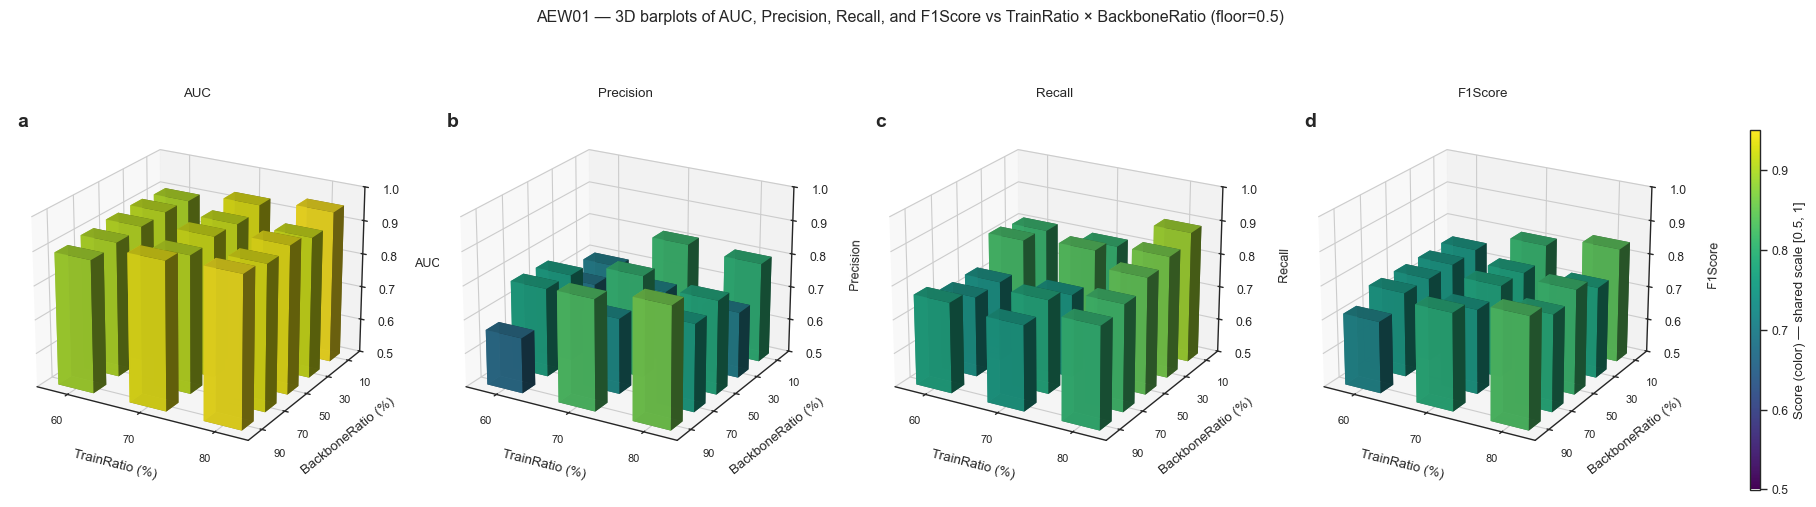

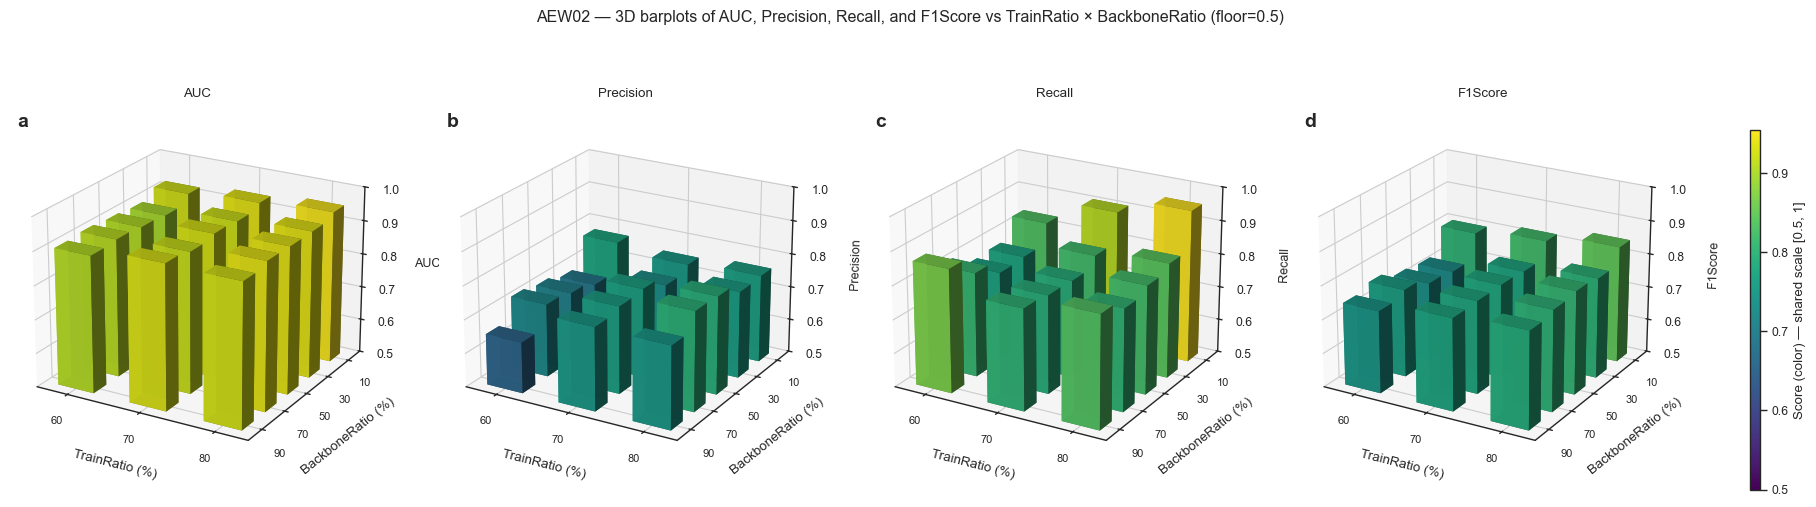

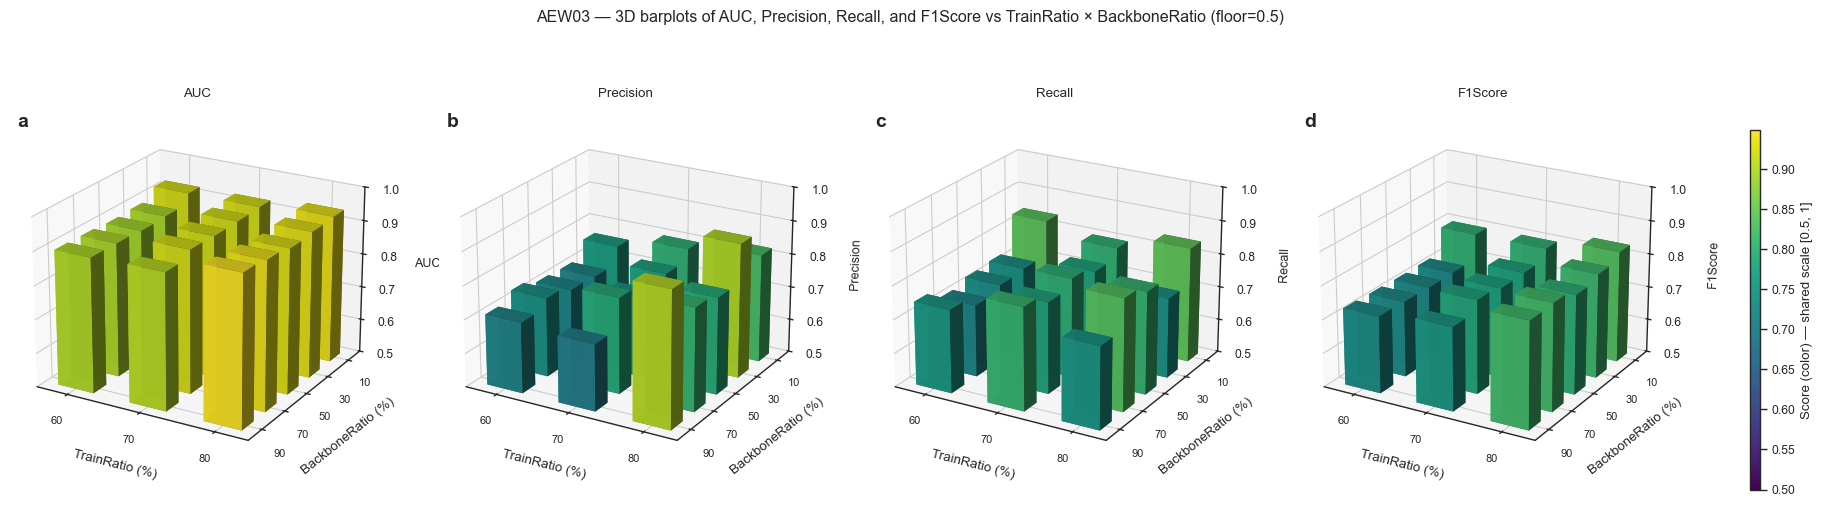

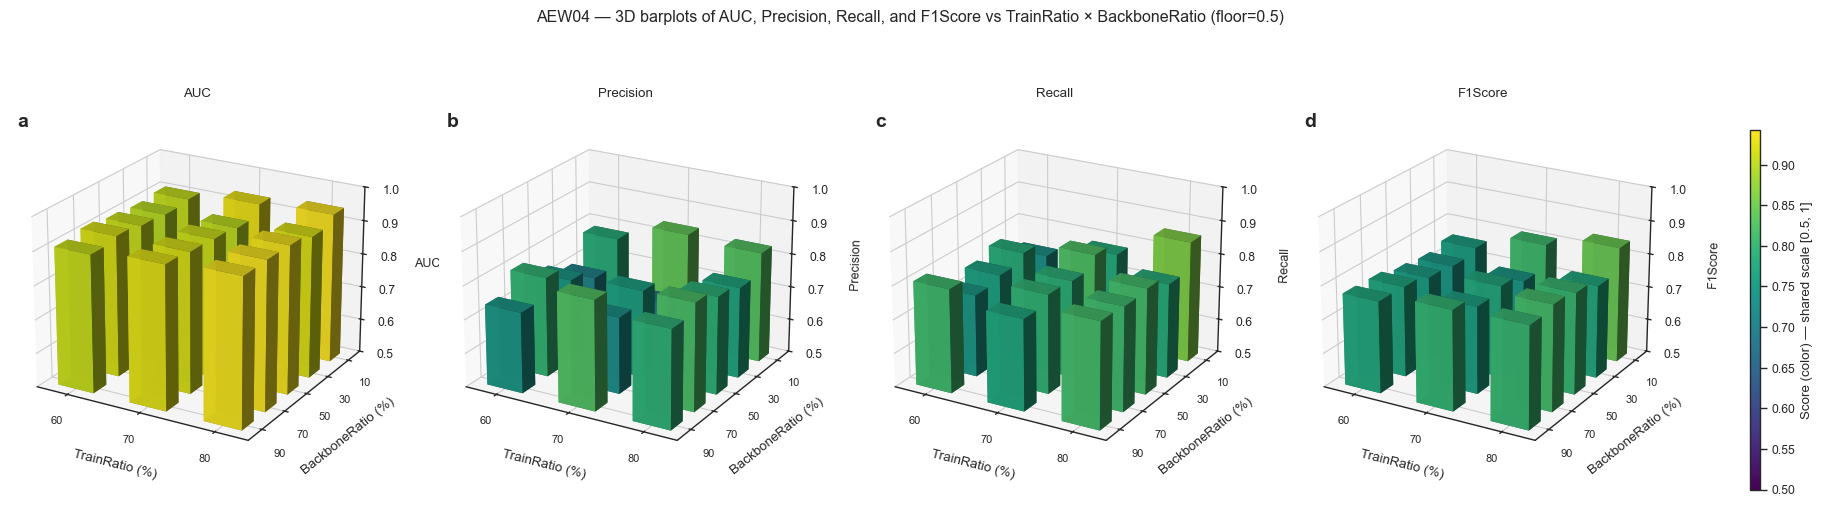

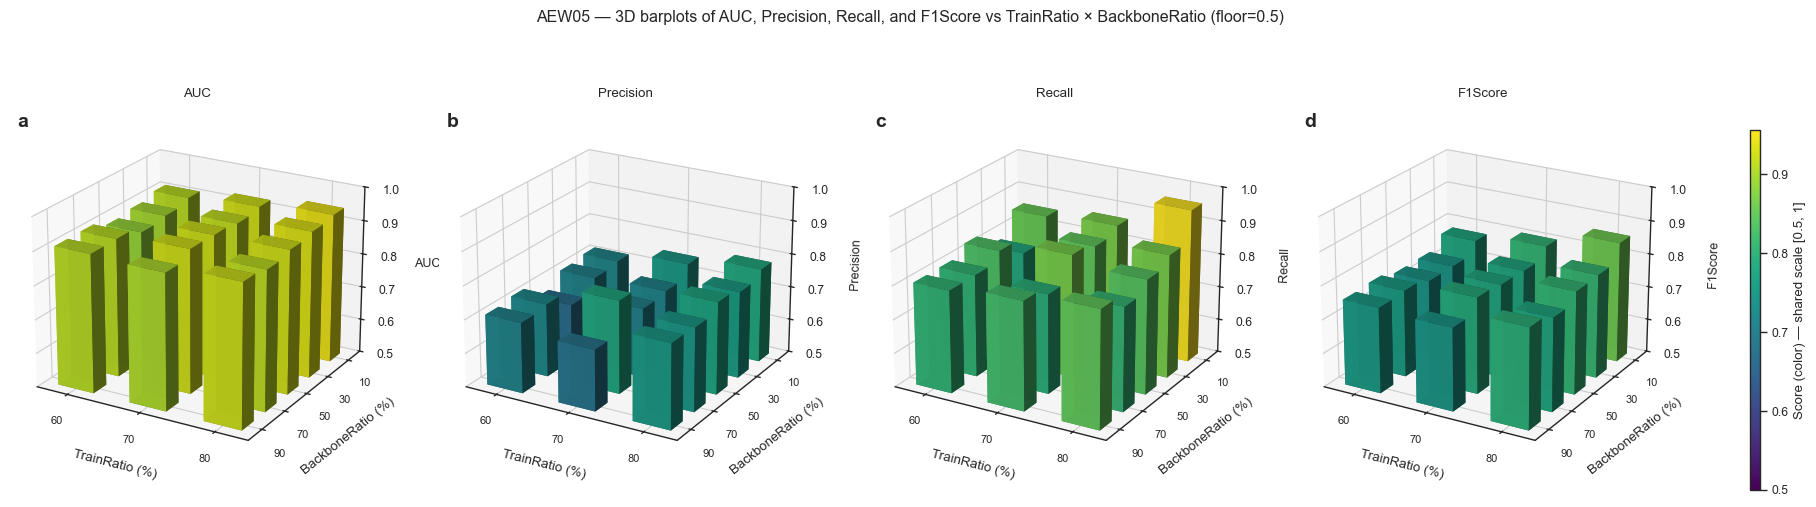

In [1]:
# %% 1x4 3D Barplots over multiple foodweb CSVs (limit=5)
import os, glob
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import seaborn as sns

# Font setup to avoid Unicode glyph issues
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]
mpl.rcParams["mathtext.fontset"] = "dejavusans"
mpl.rcParams["axes.unicode_minus"] = False

# === Config ===
RESULTS_DIR = "../../src/matlab/data/result_sweep_trainRatio_60-80_backboneRatio_10-90/prediction_scores_logs"
GLOB_PATTERNS = ["*_results_random.csv", "*_results_*.csv", "*_result_*.csv"]
MAX_SHOW = 5

DX = DY = 0.5        # bar thickness
FLOOR = 0.5          # common floor for all metrics
VIEW_KW = dict(elev=22, azim=-60)  # common 3D view

def derive_foodweb_from_filename(path: str) -> str:
    base = os.path.basename(path)
    name, _ = os.path.splitext(base)
    # limpia tokens comunes
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    name = "_".join([p for p in name.split("_") if p])
    return name

def pick_column(df: pd.DataFrame, *opts) -> str:
    norm_names = {c.lower().replace(" ", "").replace("_", ""): c for c in df.columns}
    for o in opts:
        k = o.lower().replace("_", "")
        if k in norm_names:
            return norm_names[k]
    raise KeyError(f"None of {opts} found in columns: {list(df.columns)}")

def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s.astype(str).str.replace("%","",regex=False).str.strip(), errors="coerce")

def plot_foodweb_file(csv_path: str):
    # === Load & helpers ===
    df = pd.read_csv(csv_path)

    train_col    = pick_column(df, "TrainRatio", "train_ratio", "trainratio", "train")
    backbone_col = pick_column(df, "BackboneRatio", "backbone_ratio", "backboneratio", "backbone", "bacjboneratio")

    df[train_col]    = to_num(df[train_col])
    df[backbone_col] = to_num(df[backbone_col])

    # Ensure X/Y are in 0–100 (percent)
    for c in [train_col, backbone_col]:
        vals = df[c].dropna()
        if len(vals) and vals.max() <= 1.0:
            df[c] = df[c] * 100

    # Metric columns with flexible aliases
    metric_aliases = {
        "AUC":       ("AUC", "auc"),
        "Precision": ("Precision", "precision", "prec"),
        "Recall":    ("Recall", "recall", "tpr", "sensitivity"),
        "F1Score":   ("F1Score", "f1score", "f1_score", "f1"),
    }
    metric_cols = {m: pick_column(df, *aliases) for m, aliases in metric_aliases.items()}

    # Common X/Y indices; invert Y (BackboneRatio descending)
    xr = np.sort(df[train_col].dropna().unique())
    yr = np.sort(df[backbone_col].dropna().unique())[::-1]

    # Build metric grids
    grids = {}
    for m, col in metric_cols.items():
        tmp = (df.groupby([train_col, backbone_col], as_index=False)[col]
                 .mean().rename(columns={col: "val"}))
        grid = (tmp.pivot(index=train_col, columns=backbone_col, values="val")
                  .reindex(index=xr, columns=yr))
        grids[m] = grid

    # Global normalization for shared colorbar
    vmax_global = max(float(np.nanmax(g.values)) for g in grids.values())
    cmap = cm.viridis
    norm = colors.Normalize(vmin=FLOOR, vmax=vmax_global)

    # === Plot 1x4 ===
    sns.set_theme(style="ticks", context="paper")
    fig = plt.figure(figsize=(20, 6))  # one figure per foodweb
    axes = [fig.add_subplot(1, 4, i+1, projection="3d") for i in range(4)]

    for ax, (metric_name, grid) in zip(axes, grids.items()):
        xs, ys, zs, dzh, cols = [], [], [], [], []
        for i, tr in enumerate(xr):
            for j, br in enumerate(yr):
                val = grid.iloc[i, j]
                if np.isnan(val):
                    continue
                height = val - FLOOR
                if height <= 0:
                    continue
                xs.append(i - DX/2)
                ys.append(j - DY/2)
                zs.append(FLOOR)           # start at floor
                dzh.append(height)         # height = value - floor
                cols.append(cmap(norm(val)))

        ax.bar3d(xs, ys, zs, DX, DY, dzh, shade=True, color=cols, edgecolor="none", alpha=0.95)

        # Axes and limits (unchanged logic)
        ax.set_title(metric_name)
        ax.set_xlabel("TrainRatio (%)", labelpad=6)
        ax.set_ylabel("BackboneRatio (%)", labelpad=6)
        ax.set_zlabel(f"{metric_name}", labelpad=8, fontsize=9)
        ax.set_xticks(range(len(xr)))
        ax.set_xticklabels([f"{int(v):d}" if float(v).is_integer() else f"{v:g}" for v in xr], fontsize=8)
        ax.set_yticks(range(len(yr)))
        ax.set_yticklabels([f"{int(v):d}" if float(v).is_integer() else f"{v:g}" for v in yr], fontsize=8)
        ax.set_zlim(FLOOR, 1.0)
        ax.view_init(**VIEW_KW)

    # Panel letters (bold)
    panel_labels = ["a", "b", "c", "d"]
    for ax, lab in zip(axes, panel_labels):
        ax.text2D(0.02, 0.98, lab, transform=ax.transAxes,
                  ha="left", va="top", fontweight="bold", fontsize=14)

    # Shared colorbar (right side, thinner)
    mappable = cm.ScalarMappable(norm=norm, cmap=cmap); mappable.set_array([])
    cbar_ax = fig.add_axes([0.92, 0.18, 0.005, 0.60])  # [left, bottom, width, height]
    cb = plt.colorbar(mappable, cax=cbar_ax, aspect=30)
    cb.set_label("Score (color) — shared scale [0.5, 1]")

    # Figure title with foodweb name
    fw_name = derive_foodweb_from_filename(csv_path)
    fig.suptitle(f"{fw_name} — 3D barplots of AUC, Precision, Recall, and F1Score vs TrainRatio × BackboneRatio (floor=0.5)", y=0.98)

    # Spacing
    plt.subplots_adjust(left=0.05, right=0.88, bottom=0.12, top=0.90, wspace=0.15)
    plt.show()

# === Discover up to 5 CSVs and plot each ===
all_files = []
for pat in GLOB_PATTERNS:
    all_files.extend(glob.glob(os.path.join(RESULTS_DIR, pat)))

# Ordena para reproducibilidad y limita a 5
all_files = sorted(set(all_files))[:MAX_SHOW]

if not all_files:
    raise FileNotFoundError(f"No CSVs found in {RESULTS_DIR} with patterns {GLOB_PATTERNS}")

for fp in all_files:
    try:
        plot_foodweb_file(fp)
    except Exception as e:
        print(f"[Skip] {fp}: {e}")

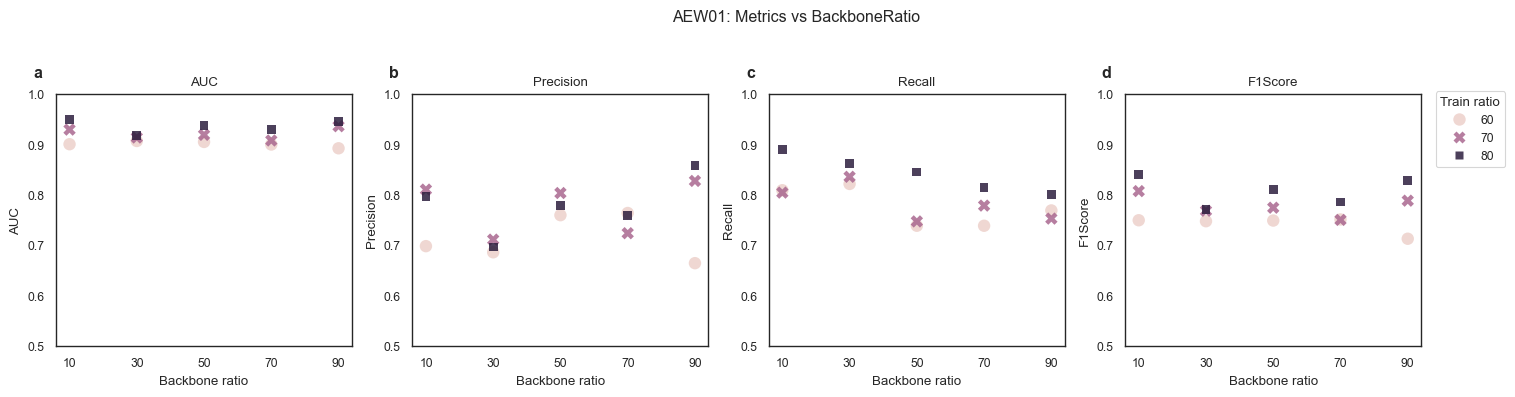

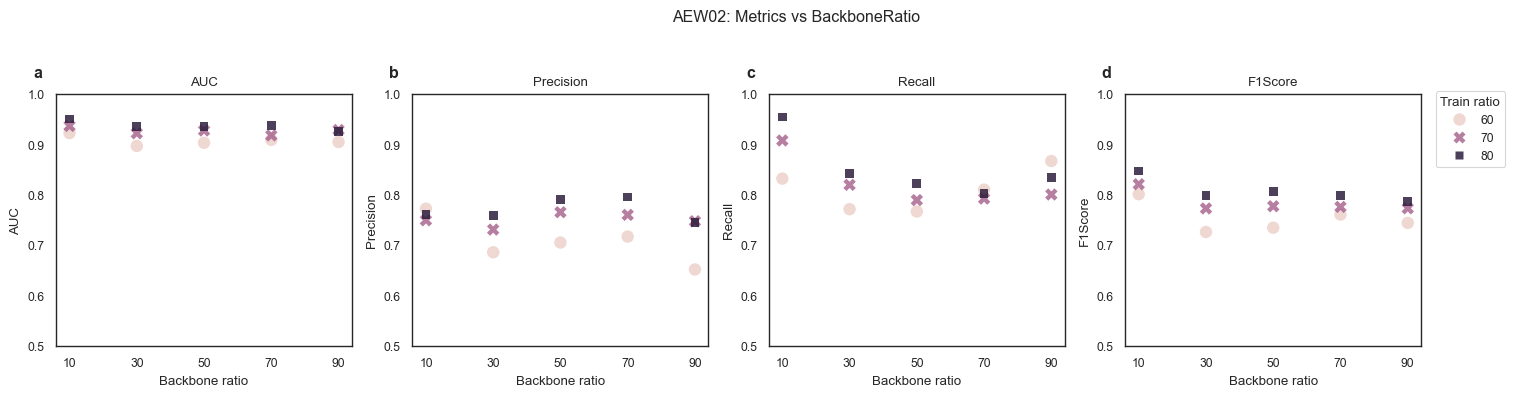

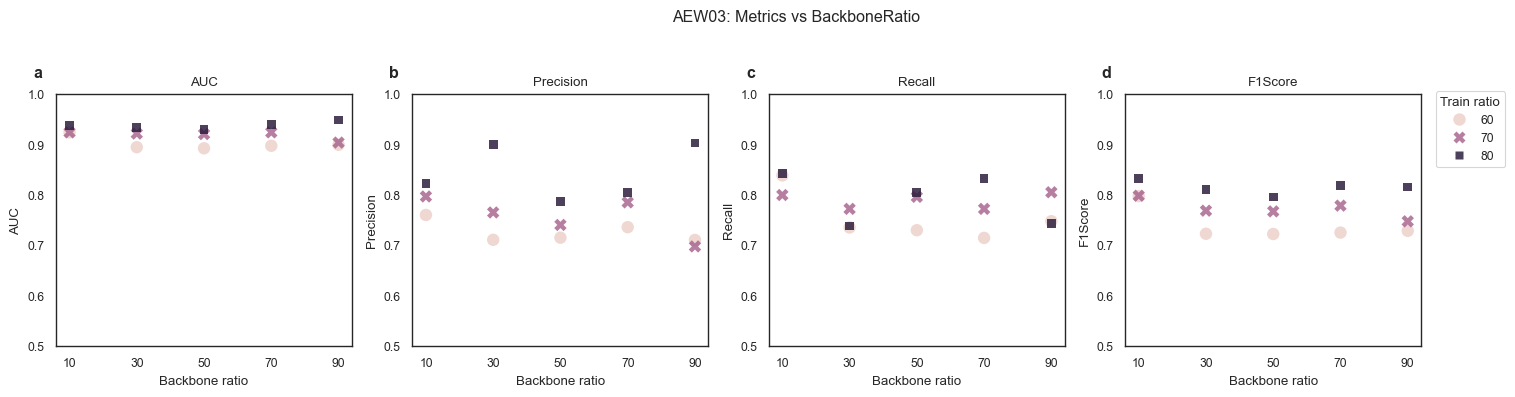

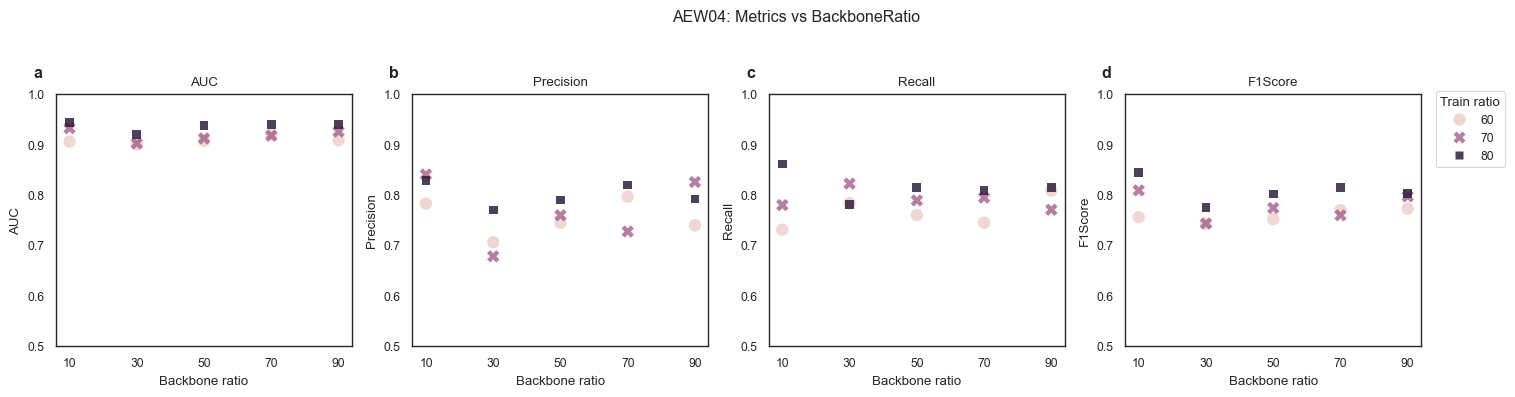

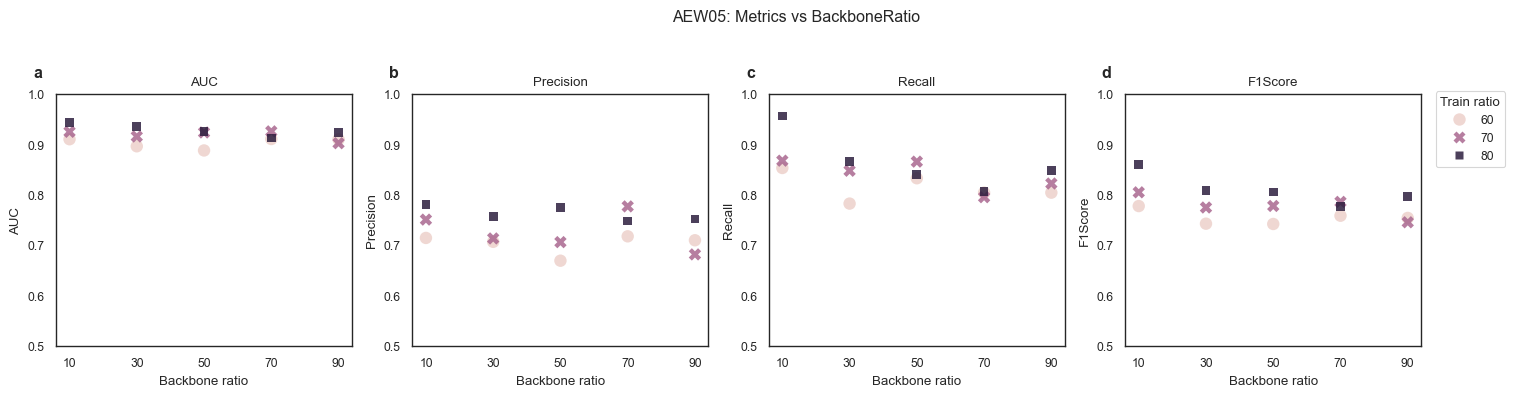

In [2]:
# %% Scatterplots row: AUC/Precision/Recall/F1Score vs BackboneRatio (loop over foodwebs, max 5 figs, one legend per fig)
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =============== Config ===============
CSV_PATH = "../../src/matlab/data/result_sweep_trainRatio_60-80_backboneRatio_10-90/prediction_scores_logs/AEW01_tax_mass_results_random.csv"
Y_LIM = (0.5, 1.0)      # set to None to auto-scale
POINT_SIZE = 80
ALPHA = 0.85
# Loop config
INPUT_DIR = os.path.dirname(CSV_PATH)
GLOB_PATTERNS = ["*_results_random.csv", "*_results_*.csv", "*_result_*.csv"]
MAX_SHOW = 5
# ======================================

def derive_foodweb_from_filename(path: str) -> str:
    base = os.path.basename(path)
    name, _ = os.path.splitext(base)
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    name = "_".join([p for p in name.split("_") if p])
    return name

def pick_col(cols, candidates):
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    raise KeyError(f"None of {candidates} found in columns: {list(cols)}")

def plot_metrics_for_csv(csv_path: str):
    # Load
    df = pd.read_csv(csv_path)

    # Find required columns (case-insensitive fallbacks)
    backbone_col = pick_col(df.columns, ["BackboneRatio", "Backbone_Ratio", "Backbone", "b_ratio"])
    auc_col       = pick_col(df.columns, ["AUC"])
    precision_col = pick_col(df.columns, ["Precision"])
    recall_col    = pick_col(df.columns, ["Recall"])
    f1_col        = pick_col(df.columns, ["F1Score", "F1_Score", "F1"])

    # Optional hue column if present
    train_col = None
    for cand in ["TrainRatio", "Train_Ratio", "train_ratio"]:
        if cand in df.columns:
            train_col = cand
            break

    # Coerce numerics and drop missing
    for c in [backbone_col, auc_col, precision_col, recall_col, f1_col]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df_ = df.dropna(subset=[backbone_col, auc_col, precision_col, recall_col, f1_col])

    # (Optional) filter to a single train ratio (e.g., 80)
    # if train_col:
    #     df_ = df_[df_[train_col] == 80]

    # Style
    sns.set_theme(style="white", context="paper")

    # Plot: single row with 4 columns
    metrics = [
        ("AUC", auc_col),
        ("Precision", precision_col),
        ("Recall", recall_col),
        ("F1Score", f1_col),
    ]

    fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharex=True)
    scatter_kwargs = dict(s=POINT_SIZE, alpha=ALPHA, edgecolor="none")

    # helper to force integer-like backbone ticks (percent steps)
    def set_integer_like_xticks(ax):
        try:
            xs = sorted(df_[backbone_col].dropna().unique())
            if len(xs) and all(float(x).is_integer() for x in xs):
                ax.set_xticks(xs)
        except Exception:
            pass

    # Panel letters
    panel_letters = ["a", "b", "c", "d"]

    # Draw panels
    handles_labels_ax = None
    for i, (mname, mcol) in enumerate(metrics):
        ax = axs[i]
        if train_col:
            # Put legend only on the first axis; we'll extract it and place a single figure legend later
            show_legend = (i == 0)
            g = sns.scatterplot(
                data=df_, x=backbone_col, y=mcol,
                hue=train_col, style=train_col,
                ax=ax, legend=show_legend, **scatter_kwargs
            )
            if show_legend:
                handles_labels_ax = ax  # remember to harvest legend from here
        else:
            g = sns.scatterplot(data=df_, x=backbone_col, y=mcol, ax=ax, **scatter_kwargs)

        # Titles & labels
        ax.set_title(mname)
        ax.set_xlabel("Backbone ratio")
        ax.set_ylabel(mname)

        # Y limits (if configured)
        if Y_LIM:
            ax.set_ylim(*Y_LIM)

        # Integer-like xticks if backbone is percentages
        set_integer_like_xticks(ax)

        # === Panel letter (bold) OUTSIDE the panel ===
        # Place at top-left just outside each axes
        ax.annotate(
            panel_letters[i],
            xy=(0, 1), xycoords="axes fraction",
            xytext=(-10, 10), textcoords="offset points",  # left & above the top-left corner
            ha="right", va="bottom",
            fontsize="large", fontweight="bold",
            annotation_clip=False
        )

    # Figure-level legend (only if hue/style is present)
    if train_col and handles_labels_ax is not None:
        # Grab and remove the axes-level legend
        handles, labels = handles_labels_ax.get_legend_handles_labels()
        if handles_labels_ax.legend_ is not None:
            handles_labels_ax.legend_.remove()
        # Deduplicate labels while preserving order
        seen = set()
        uniq_handles, uniq_labels = [], []
        for h, l in zip(handles, labels):
            if l not in seen and l != "":
                seen.add(l)
                uniq_handles.append(h)
                uniq_labels.append(l)
        fig.legend(
            uniq_handles, uniq_labels,
            title="Train ratio",
            loc="center left", bbox_to_anchor=(0.9, 0.68), borderaxespad=0.
        )

    # Suptitle with foodweb name
    foodweb = derive_foodweb_from_filename(csv_path)
    fig.suptitle(f"{foodweb}: Metrics vs BackboneRatio")

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # leave room on right for legend and top for title
    plt.show()

# ---- Discover CSVs and plot up to MAX_SHOW ----
csv_files = []
for pat in GLOB_PATTERNS:
    csv_files.extend(sorted(glob.glob(os.path.join(INPUT_DIR, pat))))

# Deduplicate while preserving order
seen = set(); files_unique = []
for f in csv_files:
    if f not in seen:
        seen.add(f)
        files_unique.append(f)

# Fallback to the single CSV_PATH if nothing matched
if not files_unique:
    files_unique = [CSV_PATH]

for csv in files_unique[:MAX_SHOW]:
    plot_metrics_for_csv(csv)

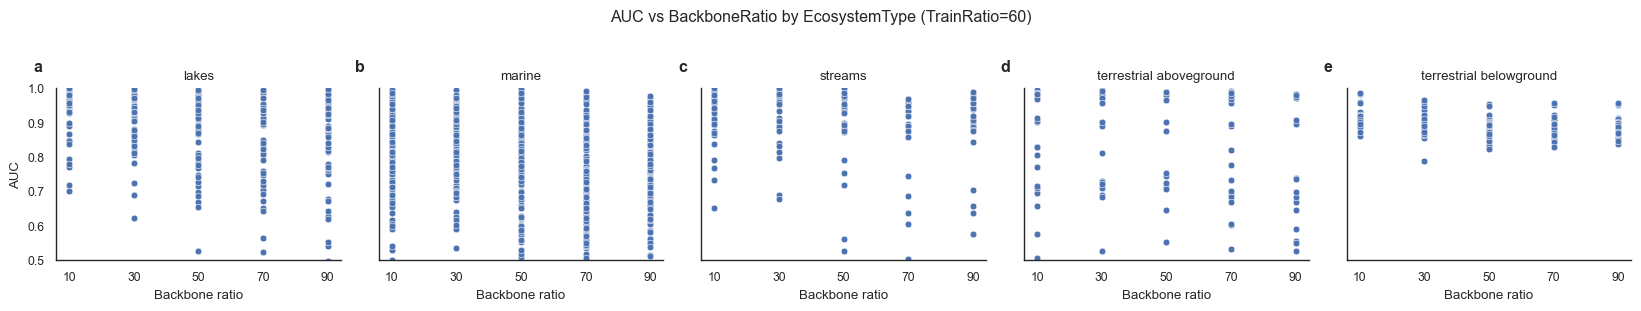

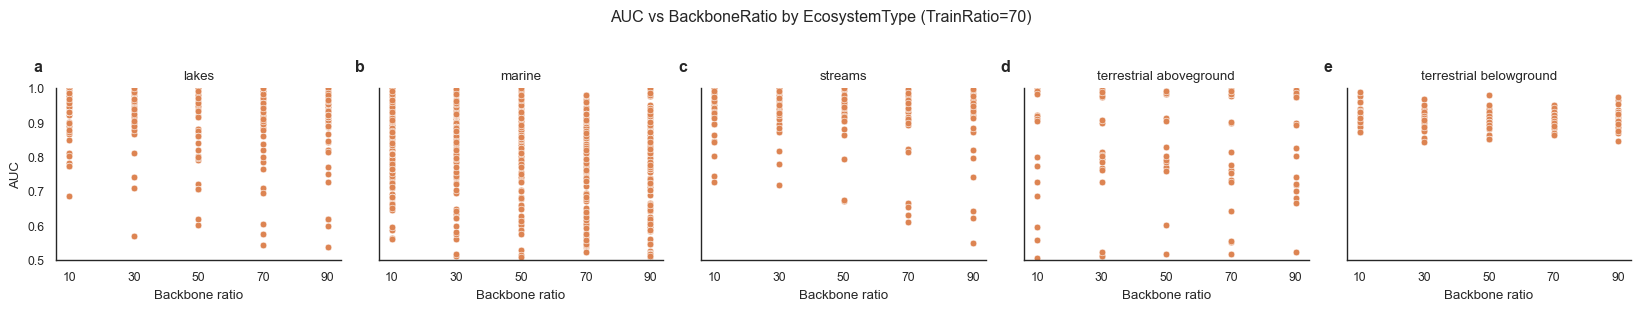

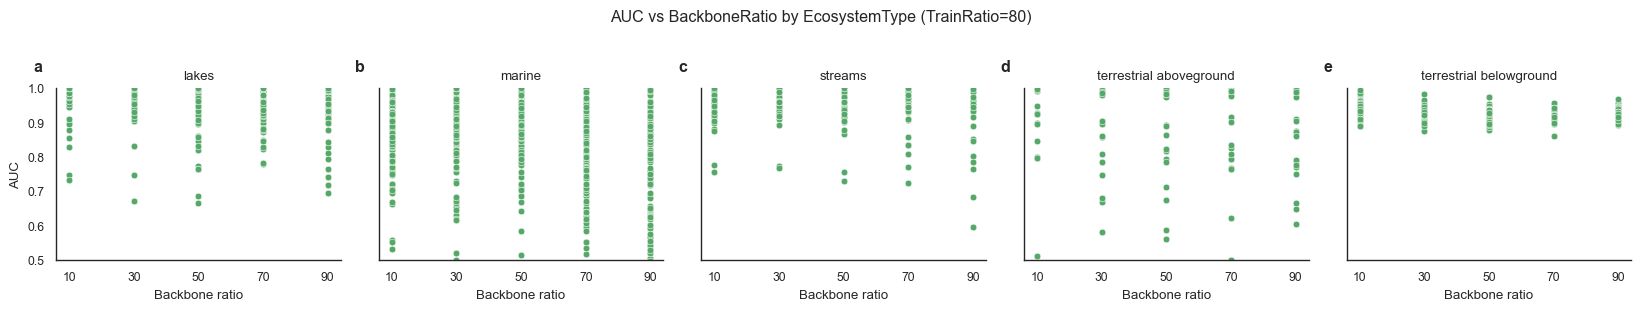

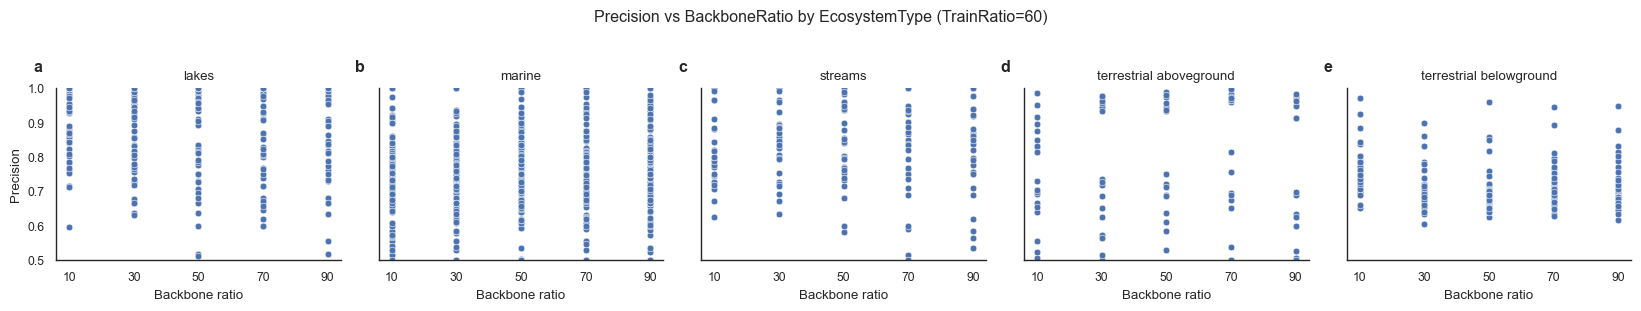

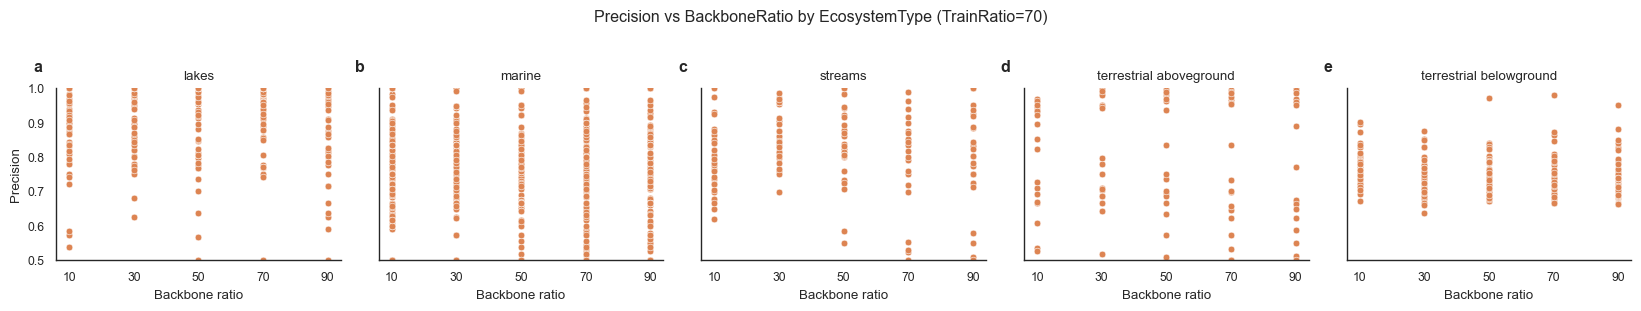

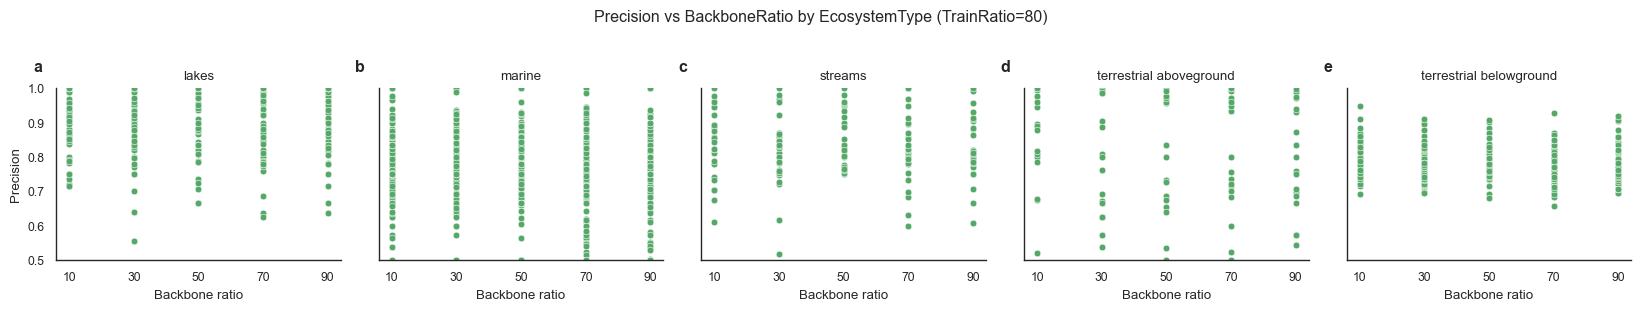

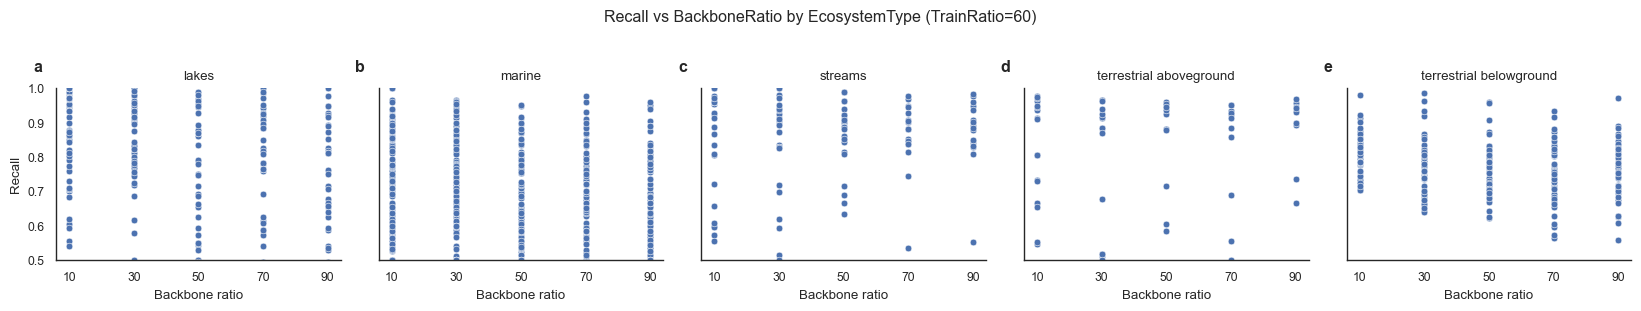

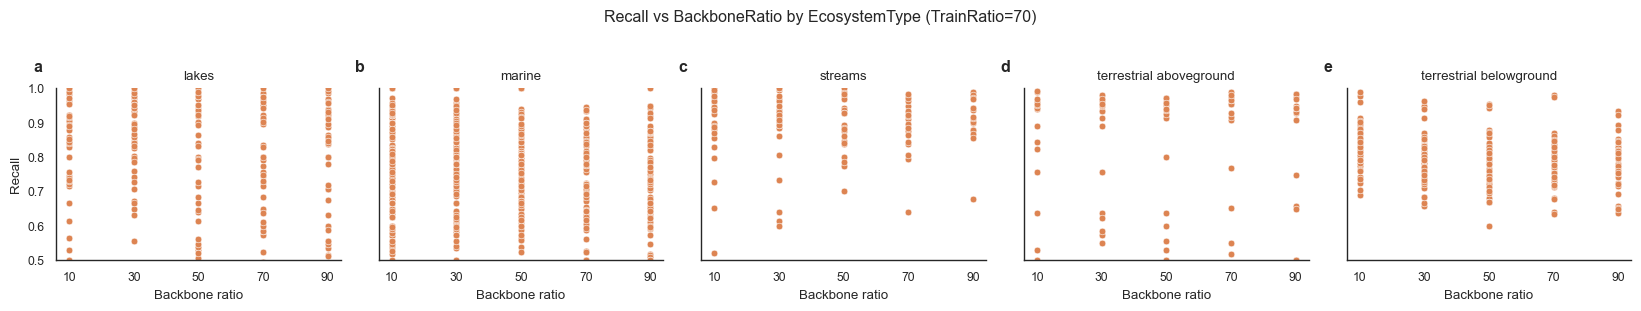

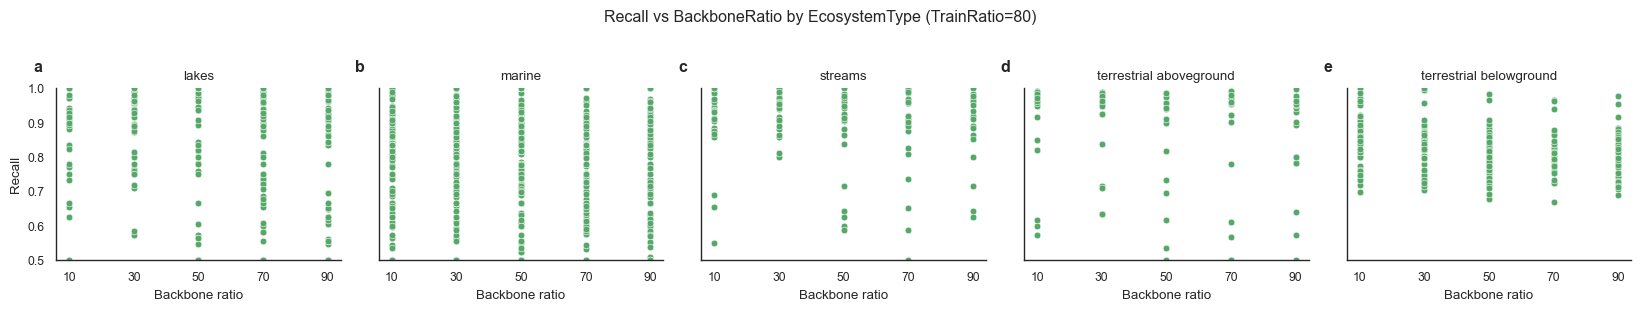

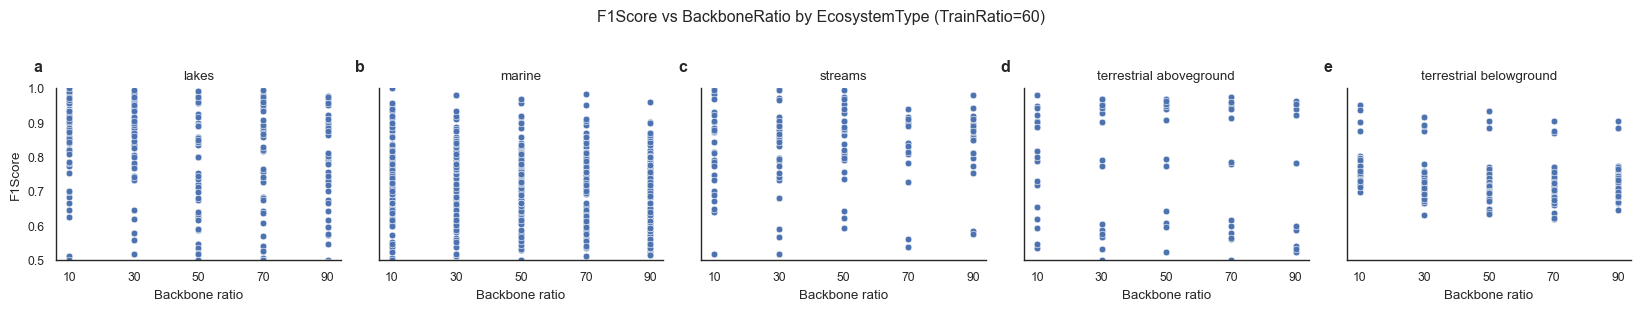

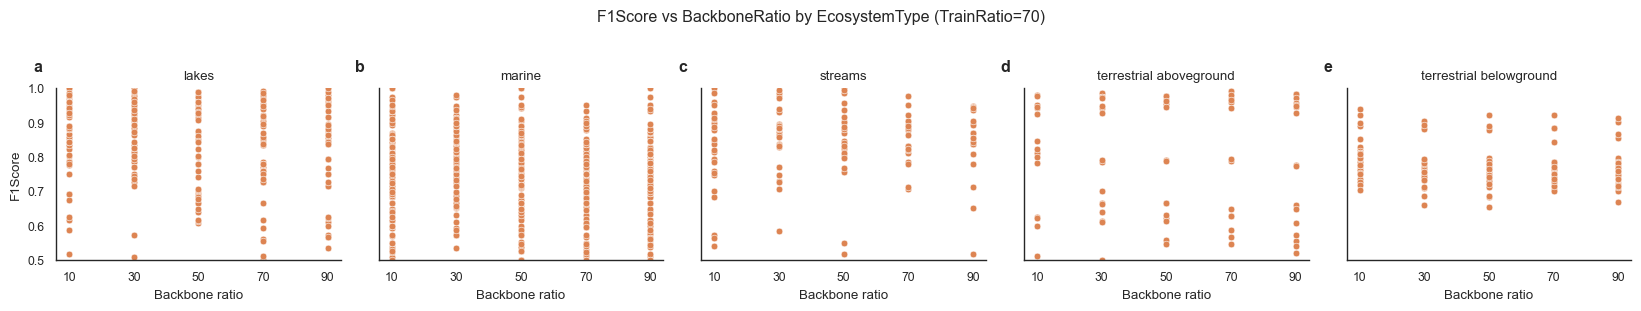

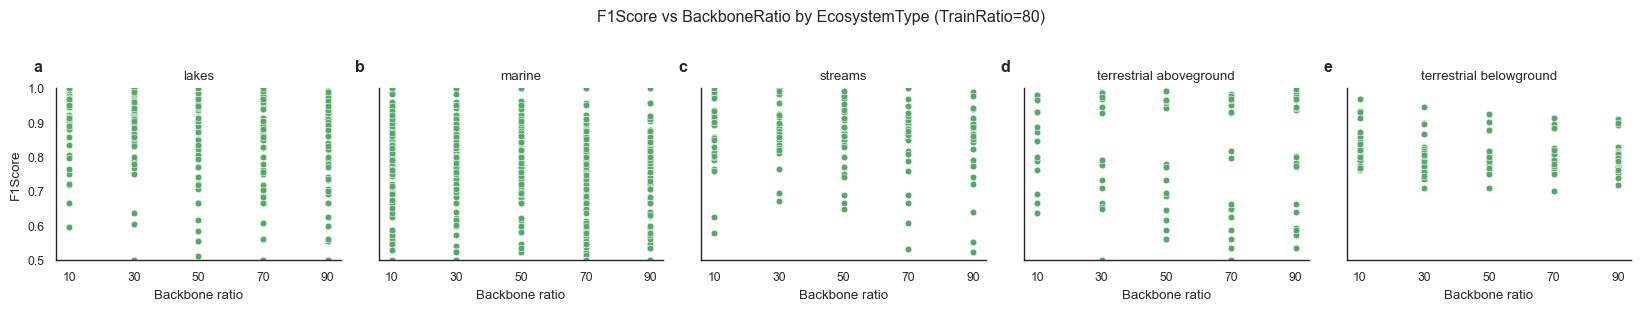

In [1]:
# %% Faceted scatter by EcosystemType (AUC vs BackboneRatio), TR=60 — robust merge + panel letters + clean titles
import os, glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ========= Config =========
CSV_PATH = "../../src/matlab/data/result_sweep_trainRatio_60-80_backboneRatio_10-90/prediction_scores_logs"  # file OR folder
GLOB_PATTERNS = ["*_results_random.csv", "*_results_*.csv", "*_result_*.csv"]
ECOSYSTEM_META_CSV = "../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
Y_LIM = (0.5, 1.0)
# ==========================

def derive_foodweb_from_filename(path: str) -> str:
    base = os.path.basename(path)
    name, _ = os.path.splitext(base)
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join([p for p in name.split("_") if p])

def sanitize_fw(name: str) -> str:
    name = os.path.splitext(os.path.basename(str(name)))[0]
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    name = "_".join([p for p in name.split("_") if p])
    return name.lower()

def pick_col(cols, candidates):
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    raise KeyError(f"None of {candidates} found among: {list(cols)}")

# Resolve INPUT_DIR whether CSV_PATH is a file or a folder
INPUT_DIR = CSV_PATH if os.path.isdir(CSV_PATH) else os.path.dirname(CSV_PATH)

# Collect CSVs (dedup to avoid pattern overlap)
files = []
for p in GLOB_PATTERNS:
    files.extend(sorted(glob.glob(os.path.join(INPUT_DIR, p))))
files = list(dict.fromkeys(files))
if not files and os.path.isfile(CSV_PATH):
    files = [CSV_PATH]

# === Additional metrics (Precision, Recall, F1Score) with identical logic/style ===
# (Keeps your existing code intact; just adds new helpers + loop.)

METRICS_TO_PLOT = [
    ("AUC", ["AUC"]),
    ("Precision", ["Precision"]),
    ("Recall",    ["Recall"]),
    ("F1Score",   ["F1Score", "F1_Score", "F1"]),
]

def build_df_for_ratio_metric(TRAIN_RATIO_TARGET: int, metric_candidates, metric_label: str) -> pd.DataFrame:
    """Build aggregated DF filtered to a given TrainRatio for a given METRIC, merged with EcosystemType."""
    rows = []
    for path in files:
        try:
            tdf = pd.read_csv(path)
            bb   = pick_col(tdf.columns, ["BackboneRatio", "Backbone_Ratio", "Backbone", "b_ratio"])
            mcol = pick_col(tdf.columns, metric_candidates)
            tr   = next((c for c in ["TrainRatio","Train_Ratio","train_ratio"] if c in tdf.columns), None)

            tdf[bb]   = pd.to_numeric(tdf[bb], errors="coerce")
            tdf[mcol] = pd.to_numeric(tdf[mcol], errors="coerce")
            if tr:
                tdf[tr] = pd.to_numeric(tdf[tr], errors="coerce")
                tdf = tdf[tdf[tr] == TRAIN_RATIO_TARGET]

            tdf = tdf.dropna(subset=[bb, mcol]).copy()
            fw_raw = derive_foodweb_from_filename(path)
            tdf["Foodweb_key"] = sanitize_fw(fw_raw)

            rows.append(
                tdf[[bb, mcol, "Foodweb_key"]].rename(columns={bb: "BackboneRatio", mcol: metric_label})
            )
        except Exception:
            continue

    df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["BackboneRatio", metric_label, "Foodweb_key"])

    # Attach Ecosystem metadata (same logic as before)
    meta = pd.read_csv(ECOSYSTEM_META_CSV)
    fw_col  = pick_col(meta.columns, ["Foodweb","FoodWeb","foodweb","Network"])
    eco_col = pick_col(meta.columns, ["EcosystemType","Ecosystem","ecosystem_type","Habitat"])

    meta2 = meta.rename(columns={fw_col: "Foodweb_meta", eco_col: "EcosystemType"})[["Foodweb_meta","EcosystemType"]].copy()
    meta2["Foodweb_key"] = meta2["Foodweb_meta"].astype(str).map(sanitize_fw)

    df = df.merge(meta2[["Foodweb_key","EcosystemType"]], on="Foodweb_key", how="left")
    df["EcosystemType"] = df["EcosystemType"].fillna("Unknown")
    return df

def plot_faceted_metric(df: pd.DataFrame, train_ratio: int, color: str, metric_label: str):
    """Plot 1-row faceted scatter for a given METRIC with panel letters and clean titles (same style)."""
    sns.set_theme(style="white", context="paper")

    eco_order = sorted(df["EcosystemType"].dropna().unique())
    if len(eco_order) > 5:
        eco_order = eco_order[:5]
    n_cols = len(eco_order) if len(eco_order) > 0 else 1

    g = sns.relplot(
        data=df[df["EcosystemType"].isin(eco_order)],
        kind="scatter",
        x="BackboneRatio", y=metric_label,
        col="EcosystemType",
        col_order=eco_order,
        col_wrap=n_cols,        # -> one row
        height=3, aspect=1.1,
        facet_kws=dict(sharex=True, sharey=True),
        color=color
    )

    # Axes formatting
    for ax in g.axes.flat:
        if Y_LIM:
            ax.set_ylim(*Y_LIM)
        try:
            xs = sorted(df["BackboneRatio"].dropna().unique())
            if len(xs) and all(float(x).is_integer() for x in xs):
                ax.set_xticks(xs)
        except Exception:
            pass

    # Titles only with ecosystem name + bold panel letters
    letters = [chr(ord('a') + i) for i in range(len(g.col_names))]
    for i, (ax, name) in enumerate(zip(g.axes.flat, g.col_names)):
        ax.set_title(name)
        ax.annotate(
            letters[i],
            xy=(0, 1), xycoords="axes fraction",
            xytext=(-10, 10), textcoords="offset points",
            ha="right", va="bottom",
            fontsize="large", fontweight="bold",
            annotation_clip=False
        )

    g.set_xlabels("Backbone ratio"); g.set_ylabels(metric_label)
    g.fig.suptitle(f"{metric_label} vs BackboneRatio by EcosystemType (TrainRatio={train_ratio})", y=1.02)
    plt.tight_layout()
    plt.show()

# === Generate the additional metric plots using the same colors per TrainRatio ===
for metric_label, candidates in METRICS_TO_PLOT:
    df60_m = build_df_for_ratio_metric(60, candidates, metric_label)
    plot_faceted_metric(df60_m, 60, "C0", metric_label)

    for tr, col in [(70, "C1"), (80, "C2")]:
        df_tr_m = build_df_for_ratio_metric(tr, candidates, metric_label)
        plot_faceted_metric(df_tr_m, tr, col, metric_label)

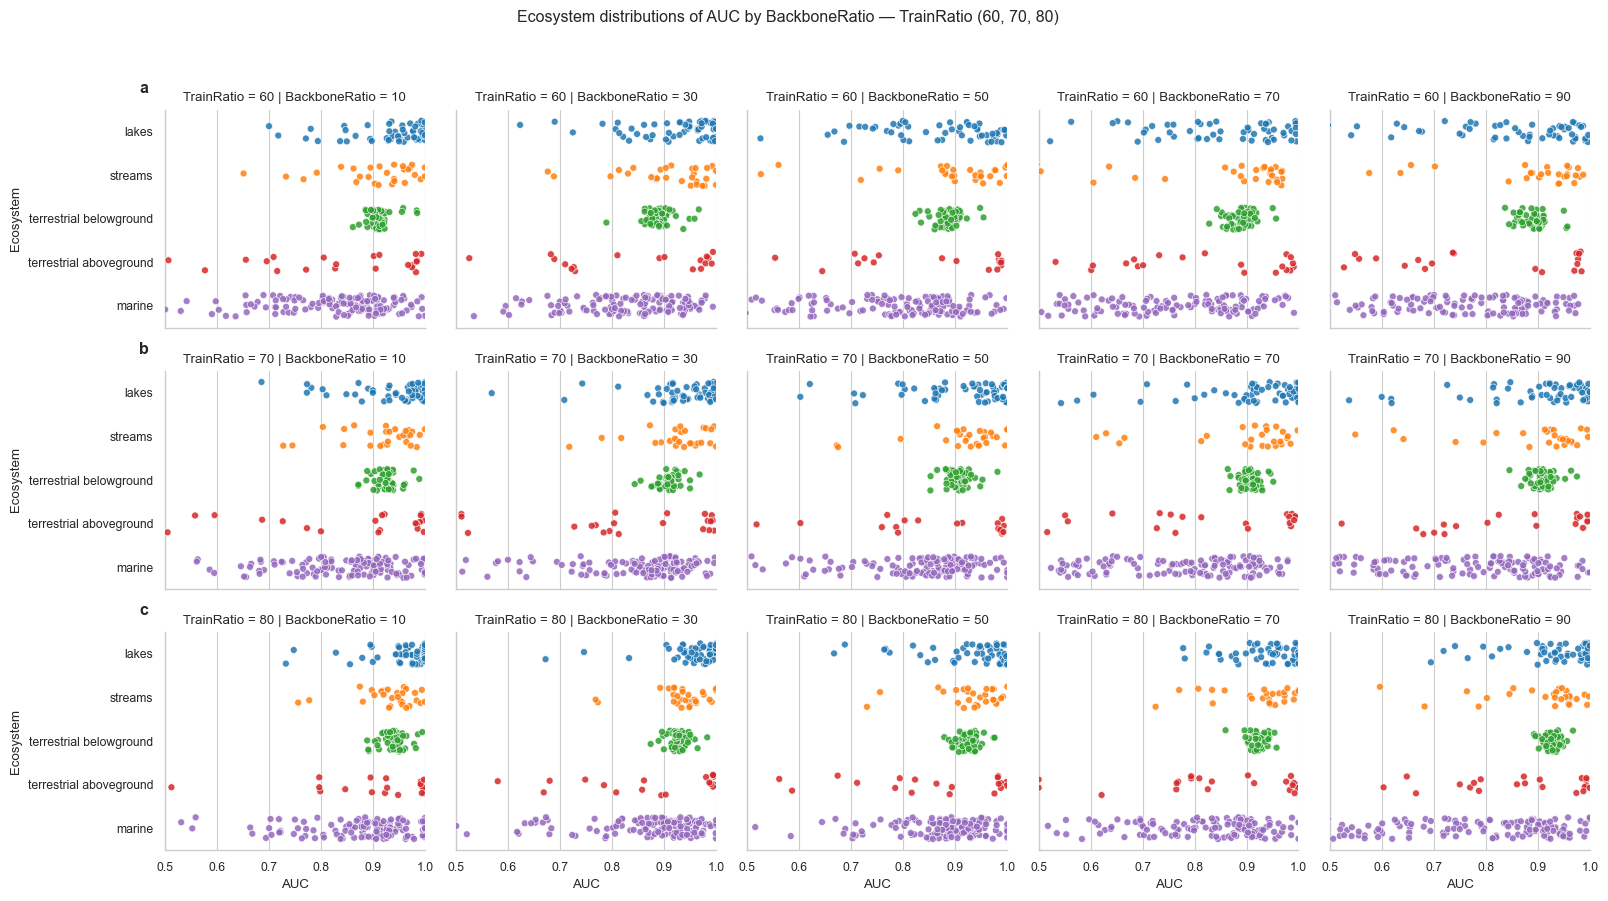

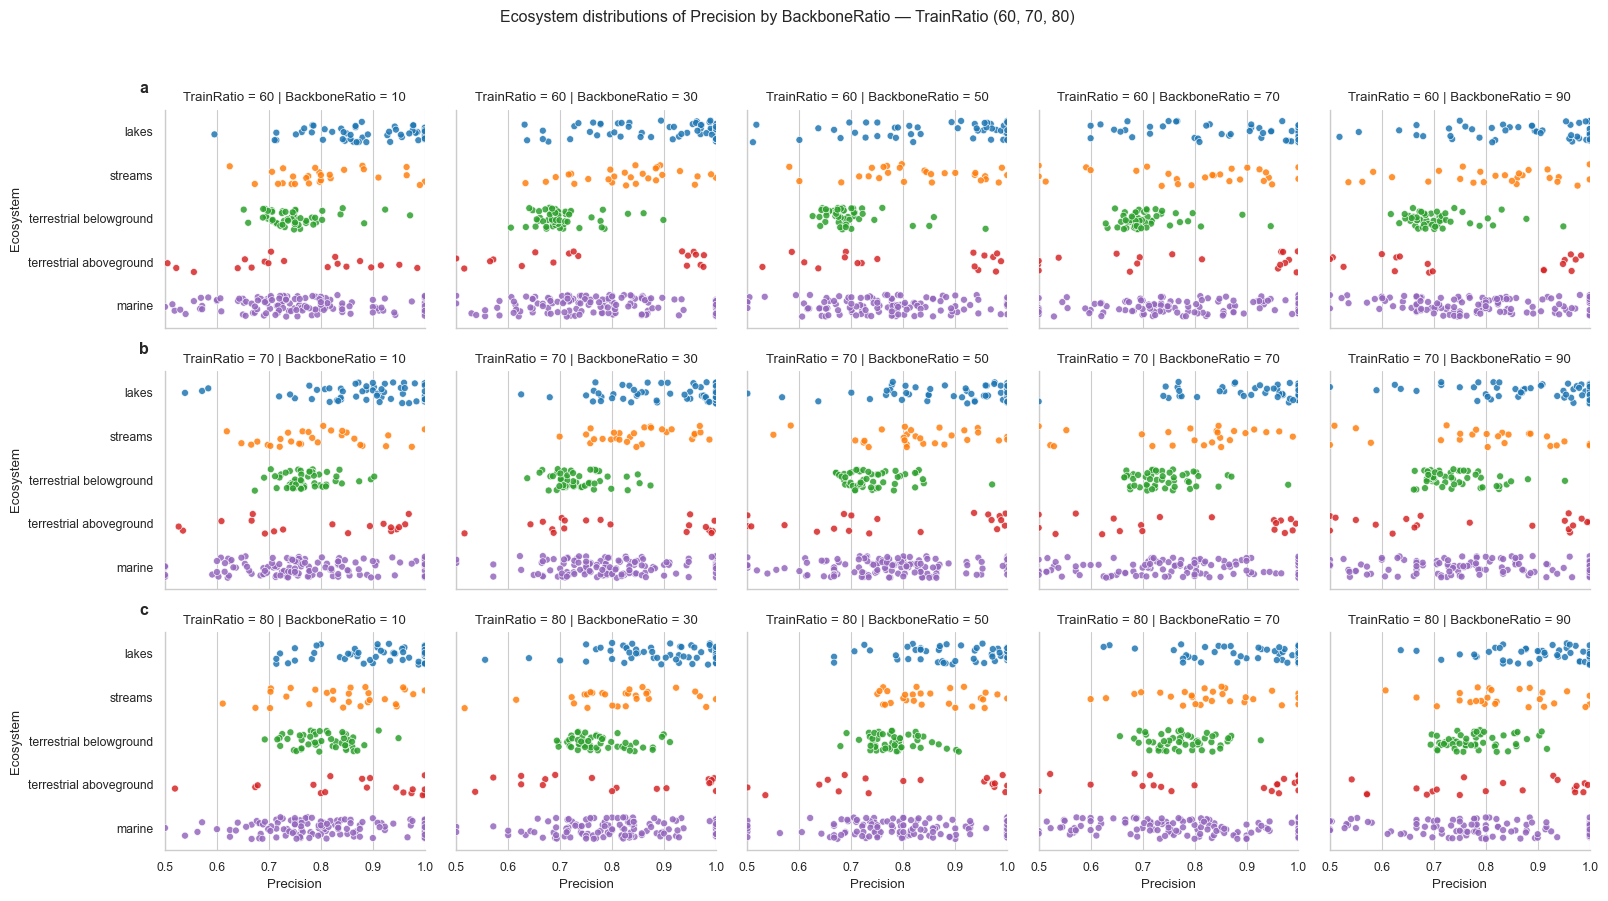

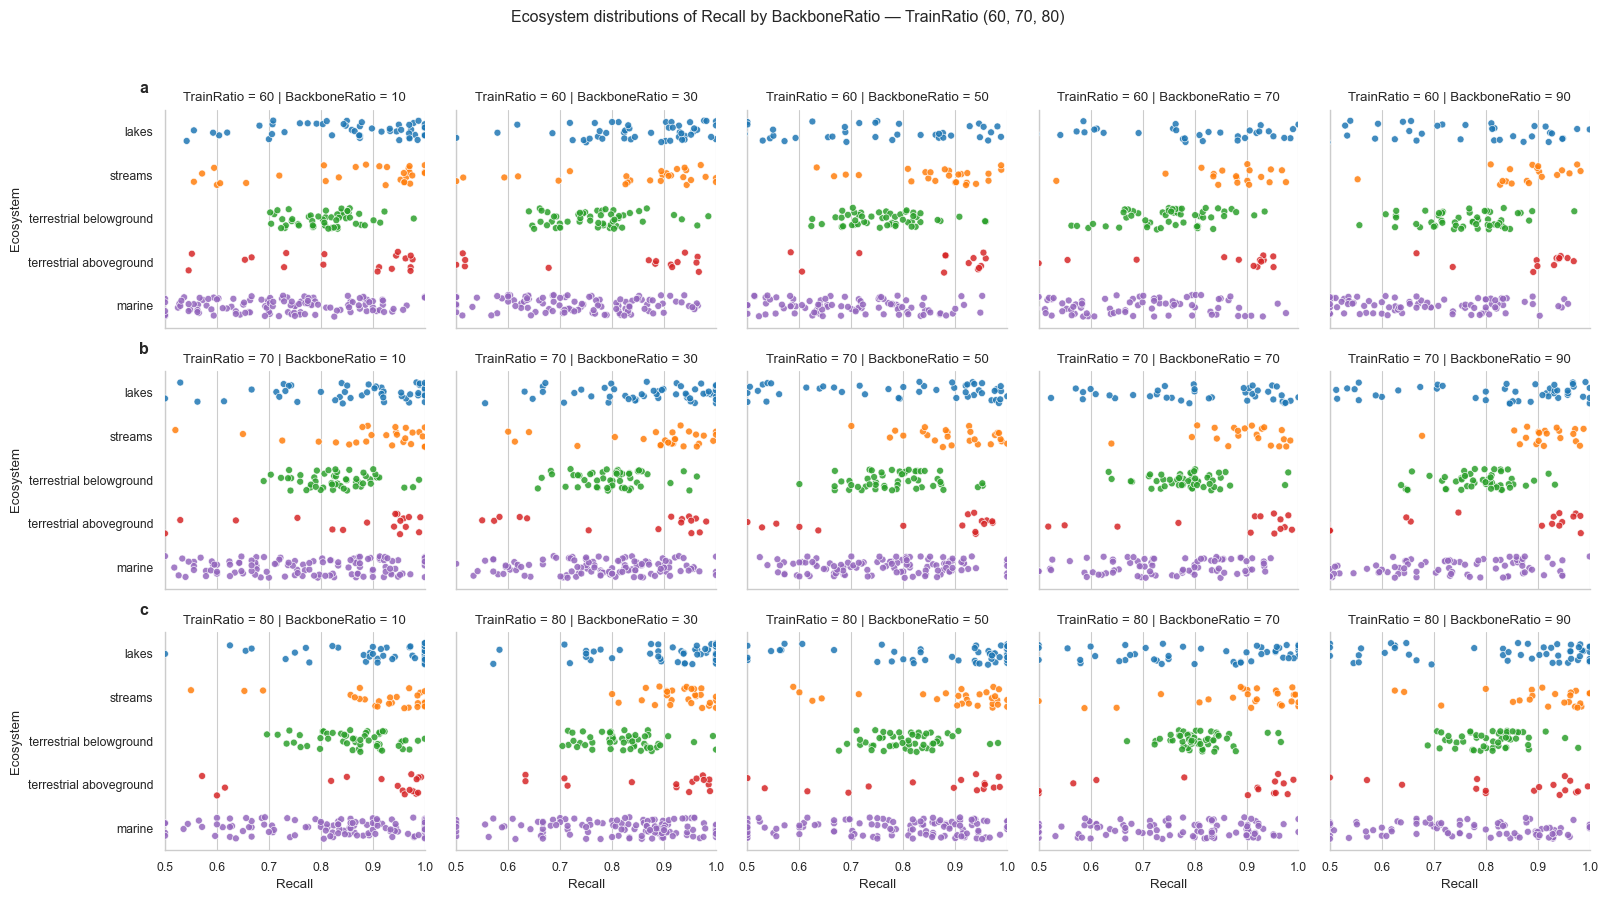

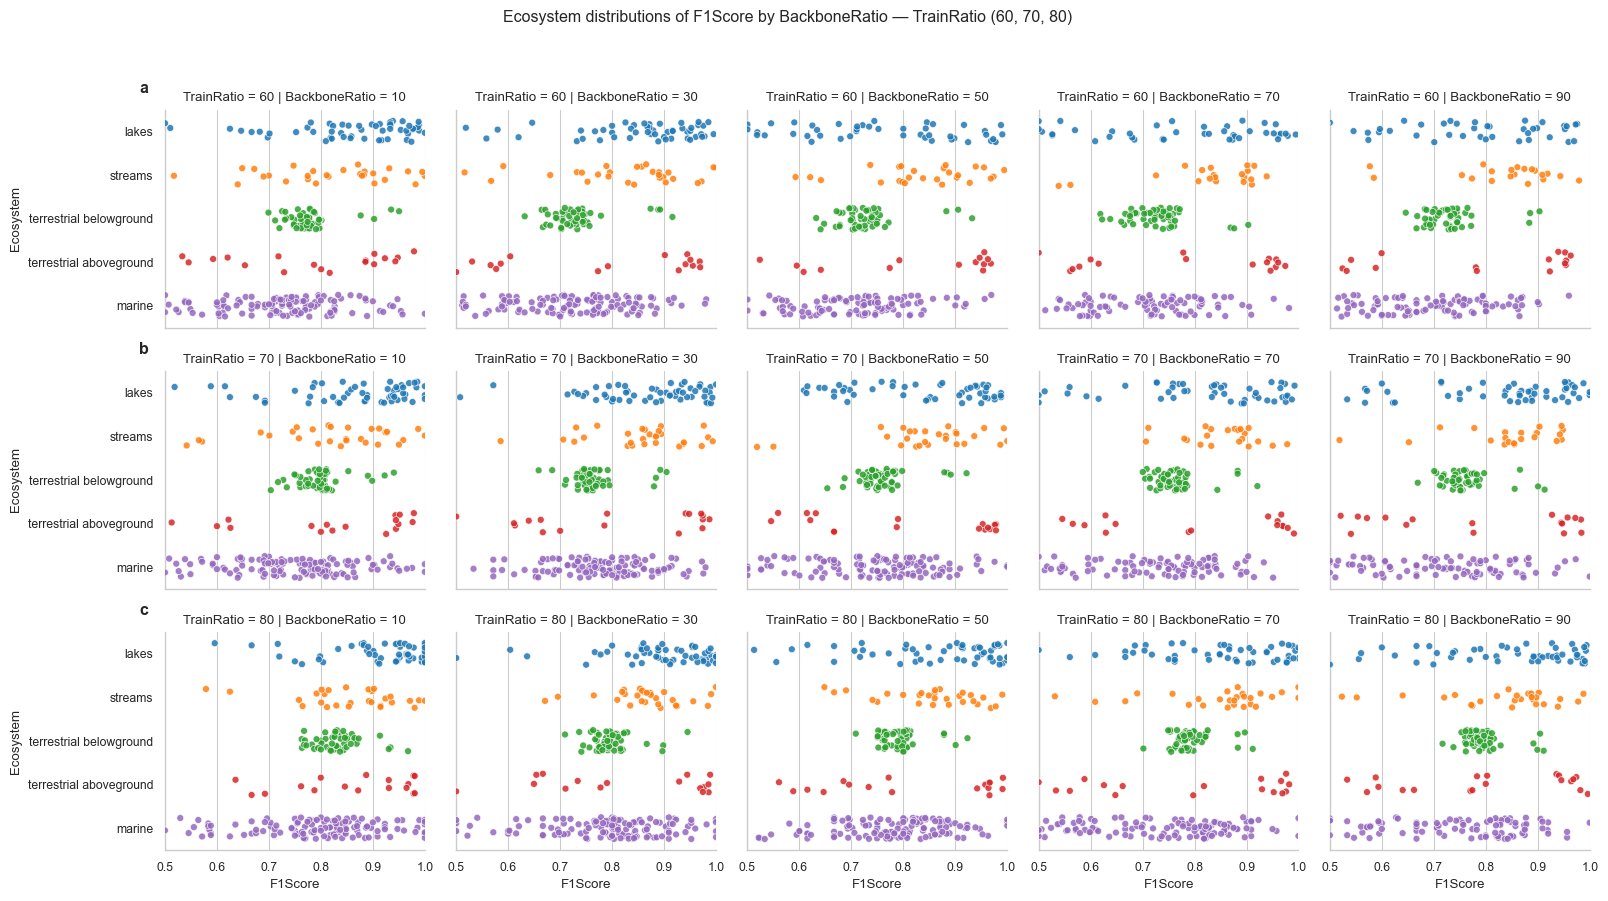

In [1]:
# %% Option B — Ecosystem-grouped strip plots per BackboneRatio (rows=TrainRatio 60/70/80, colored, white borders, no legend) + row letters a,b,c
import os, glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ========= Config =========
CSV_PATH = "../../src/matlab/data/result_sweep_trainRatio_60-80_backboneRatio_10-90/prediction_scores_logs"
GLOB_PATTERNS = ["*_results_random.csv", "*_results_*.csv", "*_result_*.csv"]
ECOSYSTEM_META_CSV = "../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
TRAIN_RATIOS = [60, 70, 80]
AUC_LIM = (0.5, 1.0)
# ==========================

def derive_foodweb_from_filename(path: str) -> str:
    base = os.path.basename(path)
    name, _ = os.path.splitext(base)
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join([p for p in name.split("_") if p])

def sanitize_fw(name: str) -> str:
    name = os.path.splitext(os.path.basename(str(name)))[0]
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    name = "_".join([p for p in name.split("_") if p])
    return name.lower()

def pick_col(cols, candidates):
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    raise KeyError(f"None of {candidates} found among: {list(cols)}")

INPUT_DIR = CSV_PATH if os.path.isdir(CSV_PATH) else os.path.dirname(CSV_PATH)

# Gather CSVs
files = []
for p in GLOB_PATTERNS:
    files.extend(sorted(glob.glob(os.path.join(INPUT_DIR, p))))
files = list(dict.fromkeys(files))
if not files and os.path.isfile(CSV_PATH):
    files = [CSV_PATH]

# ---- Build dataframe for TR in [60,70,80] and attach EcosystemType (AUC) ----
rows = []
for path in files:
    try:
        tdf = pd.read_csv(path)
        bb = pick_col(tdf.columns, ["BackboneRatio", "Backbone_Ratio", "Backbone", "b_ratio"])
        auc = pick_col(tdf.columns, ["AUC"])
        trc = next((c for c in ["TrainRatio","Train_Ratio","train_ratio"] if c in tdf.columns), None)

        tdf[bb]  = pd.to_numeric(tdf[bb], errors="coerce")
        tdf[auc] = pd.to_numeric(tdf[auc], errors="coerce")
        if trc:
            tdf[trc] = pd.to_numeric(tdf[trc], errors="coerce")
            tdf = tdf[tdf[trc].isin(TRAIN_RATIOS)]
        else:
            continue

        tdf = tdf.dropna(subset=[bb, auc]).copy()
        fw_raw = derive_foodweb_from_filename(path)
        tdf["Foodweb_key"] = sanitize_fw(fw_raw)
        tdf = tdf.rename(columns={bb: "BackboneRatio", auc: "AUC", trc: "TrainRatio"})
        rows.append(tdf[["BackboneRatio", "AUC", "Foodweb_key", "TrainRatio"]])
    except Exception:
        continue

df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["BackboneRatio","AUC","Foodweb_key","TrainRatio"])

# Attach ecosystem metadata
meta = pd.read_csv(ECOSYSTEM_META_CSV)
fw_col  = pick_col(meta.columns, ["Foodweb","FoodWeb","foodweb","Network"])
eco_col = pick_col(meta.columns, ["EcosystemType","Ecosystem","ecosystem_type","Habitat"])
meta2 = meta.rename(columns={fw_col:"Foodweb_meta", eco_col:"EcosystemType"})[["Foodweb_meta","EcosystemType"]].copy()
meta2["Foodweb_key"] = meta2["Foodweb_meta"].astype(str).map(sanitize_fw)
df = df.merge(meta2[["Foodweb_key","EcosystemType"]], on="Foodweb_key", how="left")
df["EcosystemType"] = df["EcosystemType"].fillna("Unknown")

# ---- Strip plots: rows=TrainRatio, cols=BackboneRatio, hue=EcosystemType (no legend), white borders ----
sns.set_theme(style="whitegrid", context="paper")

# Consistent ecosystem order and palette across all rows
eco_order = (
    df.groupby("EcosystemType")["AUC"].median().sort_values(ascending=False).index
    if not df.empty else None
)
palette = sns.color_palette("tab10", n_colors=len(eco_order))
palette = {eco: palette[i % len(palette)] for i, eco in enumerate(eco_order)}

br_order = sorted(df["BackboneRatio"].dropna().unique())
row_order = [r for r in TRAIN_RATIOS if r in df["TrainRatio"].unique()]

g = sns.catplot(
    data=df,
    kind="strip",
    x="AUC", y="EcosystemType",
    hue="EcosystemType",
    row="TrainRatio", row_order=row_order,         # rows: 60, 70, 80
    col="BackboneRatio", col_order=br_order,
    order=eco_order,
    palette=palette,
    jitter=0.25, alpha=0.85, dodge=False, height=3, aspect=1.1,
    edgecolor="white", linewidth=0.5,
    legend=False
)

# Formatting
for ax in g.axes.flat:
    if AUC_LIM:
        ax.set_xlim(*AUC_LIM)

g.set_xlabels("AUC")
g.set_ylabels("Ecosystem")
g.fig.suptitle("Ecosystem distributions of AUC by BackboneRatio — TrainRatio (60, 70, 80)", y=0.995)

# === Add bold row letters (a, b, c) on the first panel of each row ===
row_letters = ["a", "b", "c"]
axes_arr = g.axes
try:
    n_rows = axes_arr.shape[0] if hasattr(axes_arr, "shape") else len(row_order)
    for i in range(min(n_rows, len(row_letters))):
        ax0 = axes_arr[i, 0] if hasattr(axes_arr, "ndim") and axes_arr.ndim == 2 else axes_arr[i]
        ax0.annotate(
            row_letters[i],
            xy=(0, 1), xycoords="axes fraction",
            xytext=(-12, 10), textcoords="offset points",
            ha="right", va="bottom",
            fontsize="large", fontweight="bold",
            annotation_clip=False
        )
except Exception:
    pass

plt.tight_layout(rect=[0.02, 0, 1, 0.965])
plt.show()

# ========= Loop to generate additional metrics with identical styling =========
OTHER_METRICS = [
    ("Precision", ["Precision"]),
    ("Recall",    ["Recall"]),
    ("F1Score",   ["F1Score", "F1_Score", "F1"]),
]

for metric_label, metric_candidates in OTHER_METRICS:
    # Build df for this metric (keeping everything else intact)
    rows_m = []
    for path in files:
        try:
            tdf = pd.read_csv(path)
            bb   = pick_col(tdf.columns, ["BackboneRatio", "Backbone_Ratio", "Backbone", "b_ratio"])
            mcol = pick_col(tdf.columns, metric_candidates)
            trc  = next((c for c in ["TrainRatio","Train_Ratio","train_ratio"] if c in tdf.columns), None)

            tdf[bb]  = pd.to_numeric(tdf[bb], errors="coerce")
            tdf[mcol]= pd.to_numeric(tdf[mcol], errors="coerce")
            if trc:
                tdf[trc] = pd.to_numeric(tdf[trc], errors="coerce")
                tdf = tdf[tdf[trc].isin(TRAIN_RATIOS)]
            else:
                continue

            tdf = tdf.dropna(subset=[bb, mcol]).copy()
            fw_raw = derive_foodweb_from_filename(path)
            tdf["Foodweb_key"] = sanitize_fw(fw_raw)
            tdf = tdf.rename(columns={bb: "BackboneRatio", mcol: metric_label, trc: "TrainRatio"})
            rows_m.append(tdf[["BackboneRatio", metric_label, "Foodweb_key", "TrainRatio"]])
        except Exception:
            continue

    dfm = pd.concat(rows_m, ignore_index=True) if rows_m else pd.DataFrame(columns=["BackboneRatio",metric_label,"Foodweb_key","TrainRatio"])
    dfm = dfm.merge(meta2[["Foodweb_key","EcosystemType"]], on="Foodweb_key", how="left")
    dfm["EcosystemType"] = dfm["EcosystemType"].fillna("Unknown")

    br_order_m = sorted(dfm["BackboneRatio"].dropna().unique())
    row_order_m = [r for r in TRAIN_RATIOS if r in dfm["TrainRatio"].unique()]

    g = sns.catplot(
        data=dfm,
        kind="strip",
        x=metric_label, y="EcosystemType",
        hue="EcosystemType",
        row="TrainRatio", row_order=row_order_m,
        col="BackboneRatio", col_order=br_order_m,
        order=eco_order,
        palette=palette,
        jitter=0.25, alpha=0.85, dodge=False, height=3, aspect=1.1,
        edgecolor="white", linewidth=0.5,
        legend=False
    )

    for ax in g.axes.flat:
        if AUC_LIM:
            ax.set_xlim(*AUC_LIM)

    g.set_xlabels(metric_label)
    g.set_ylabels("Ecosystem")
    g.fig.suptitle(f"Ecosystem distributions of {metric_label} by BackboneRatio — TrainRatio (60, 70, 80)", y=0.995)

    # Row letters (a, b, c)
    axes_arr = g.axes
    try:
        n_rows = axes_arr.shape[0] if hasattr(axes_arr, "shape") else len(row_order_m)
        for i in range(min(n_rows, len(row_letters))):
            ax0 = axes_arr[i, 0] if hasattr(axes_arr, "ndim") and axes_arr.ndim == 2 else axes_arr[i]
            ax0.annotate(
                row_letters[i],
                xy=(0, 1), xycoords="axes fraction",
                xytext=(-12, 10), textcoords="offset points",
                ha="right", va="bottom",
                fontsize="large", fontweight="bold",
                annotation_clip=False
            )
    except Exception:
        pass

    plt.tight_layout(rect=[0.02, 0, 1, 0.965])
    plt.show()

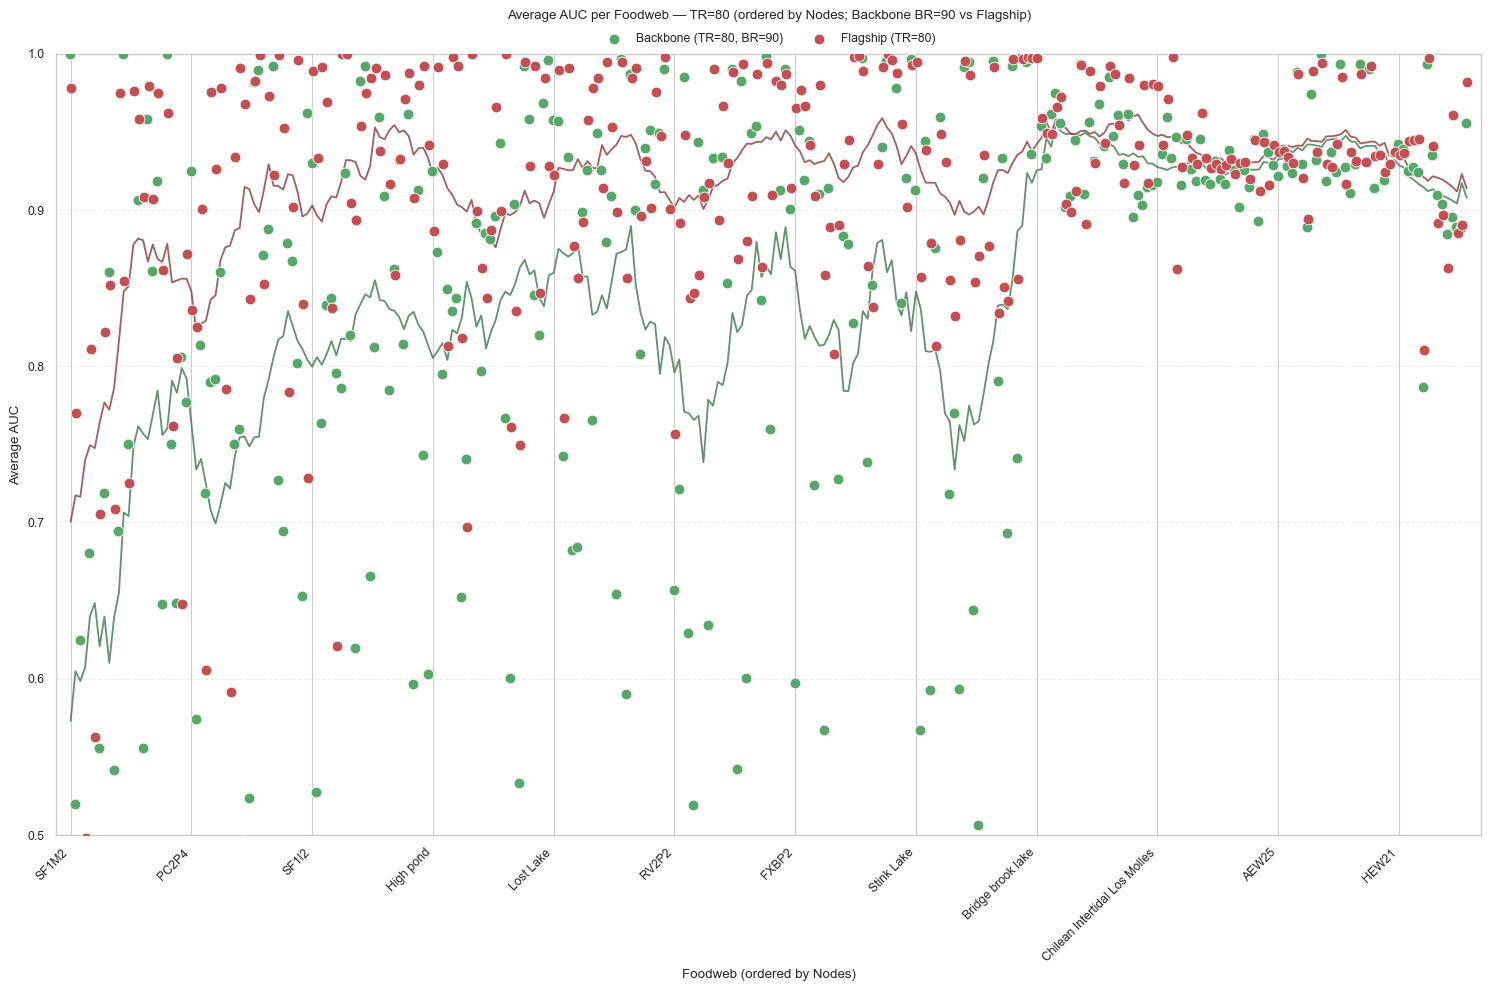

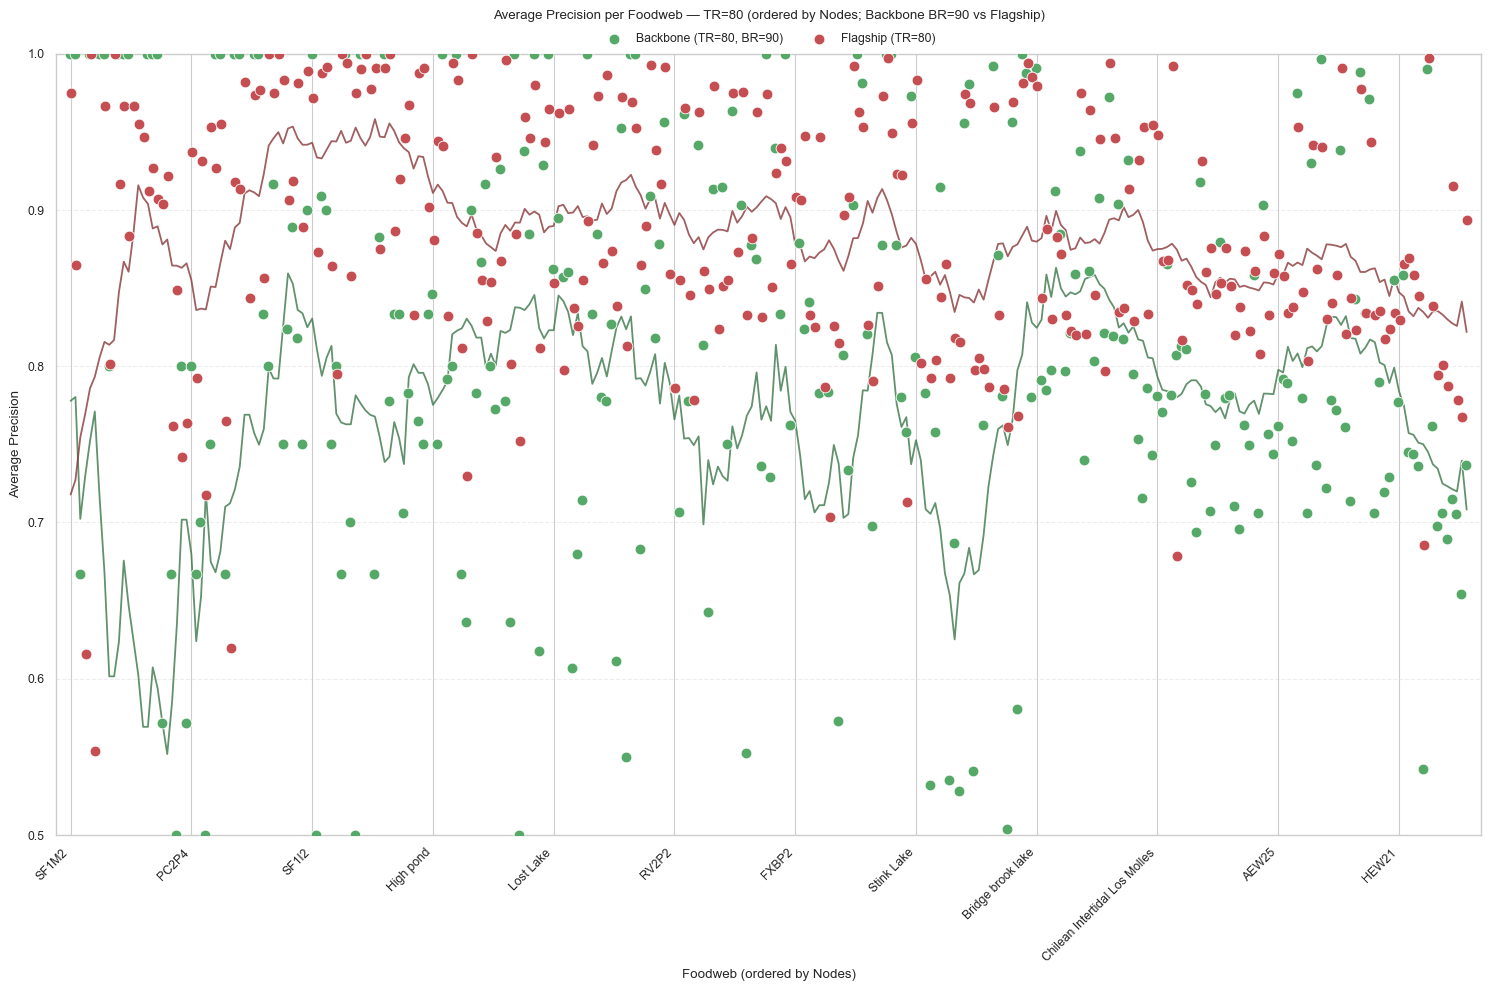

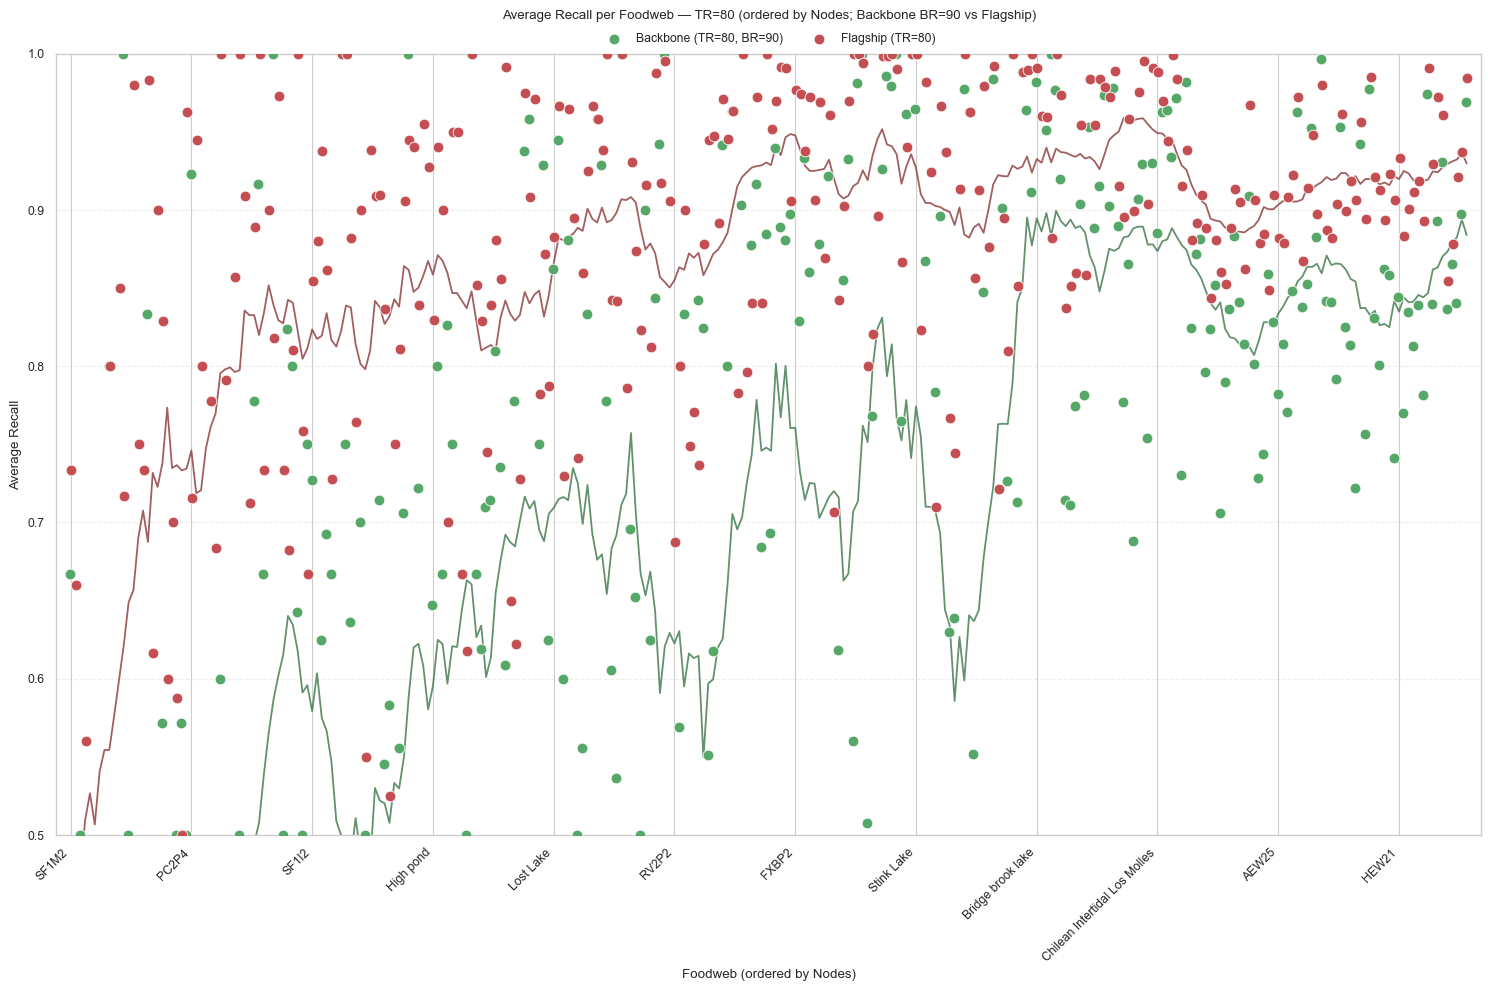

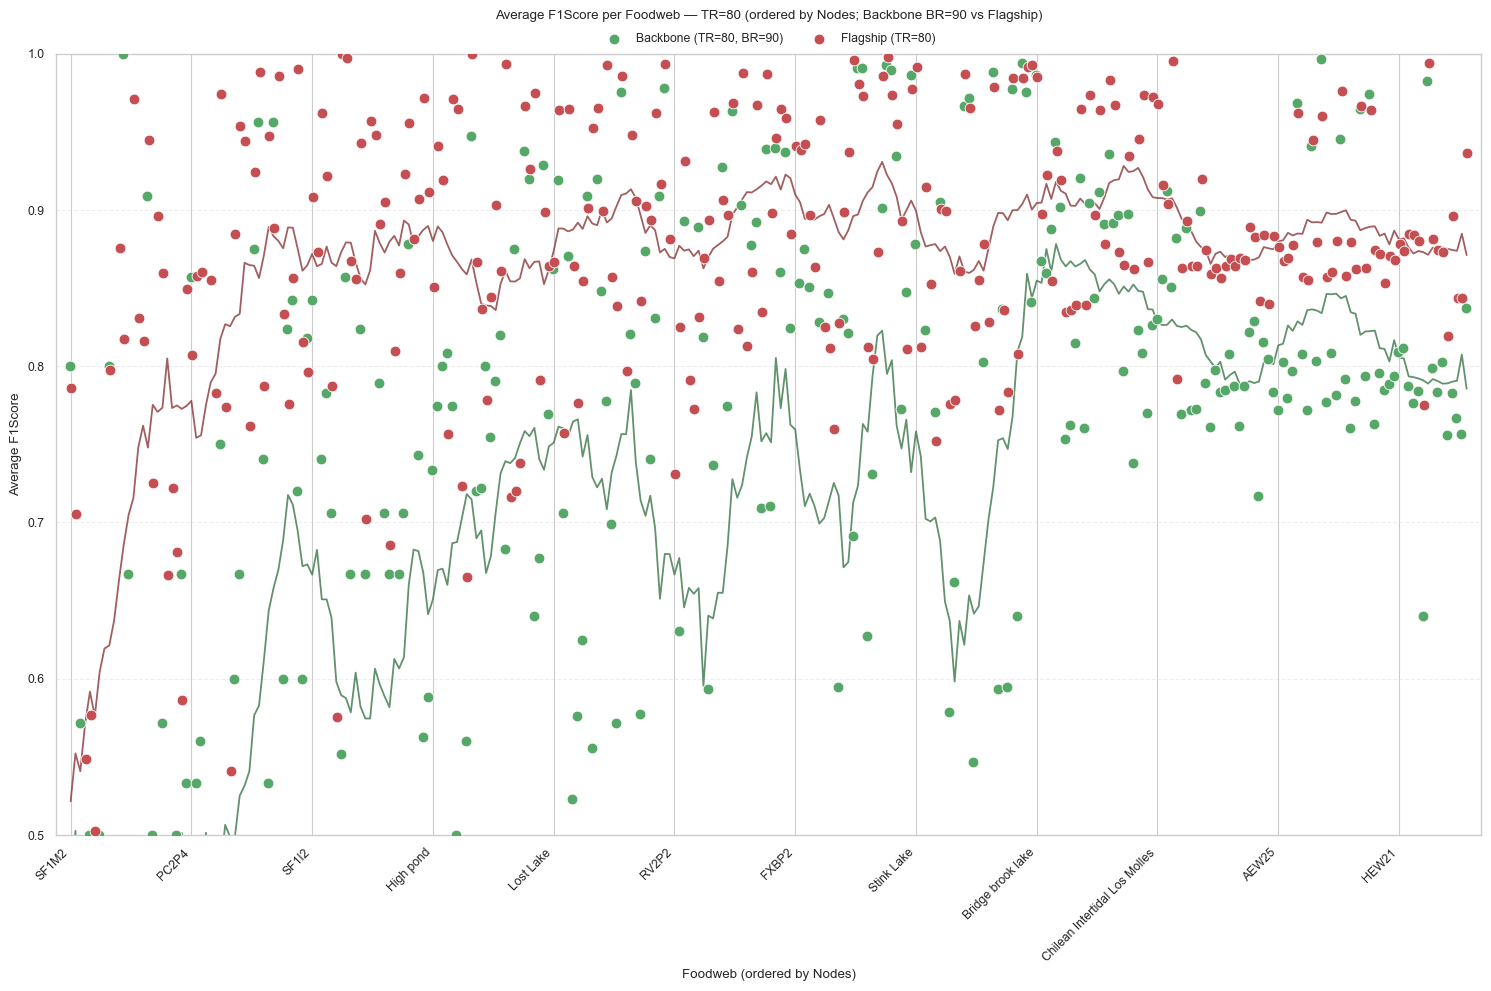

In [1]:
# %% AUC/Precision/Recall/F1Score average by foodweb (overlay two sources) — TR=80
import os, glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors  # ← for darkening colors

RESULTS_DIR_BACKBONE = "../../src/matlab/data/result_sweep_trainRatio_60-80_backboneRatio_10-90/prediction_scores_logs"
RESULTS_DIR_FLAGSHIP = "../../src/matlab/data/result_sweep_train_ratios_290/prediction_scores_logs"
ECOSYSTEM_META_CSV = "../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
GLOB_PATTERNS = ["*_results_random.csv", "*_results_*.csv", "*_result_*.csv"]

TRAIN_RATIO_TARGET = 80
BACKBONE_RATIO_TARGET = 90  # only for the BACKBONE series

sns.set_theme(style="whitegrid", context="paper")

def derive_foodweb_from_filename(path: str) -> str:
    base = os.path.basename(path)
    name, _ = os.path.splitext(base)
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join([p for p in name.split("_") if p])

def sanitize_fw(name: str) -> str:
    n = os.path.splitext(os.path.basename(str(name)))[0]
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        n = n.replace(token, "_")
    n = "_".join([p for p in n.split("_") if p])
    return n.lower()

def pick_col(cols, candidates):
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    raise KeyError(f"None of {candidates} found among: {list(cols)}")

def load_metric_means(results_dir, tr_target, br_target=None):
    files = []
    for pat in GLOB_PATTERNS:
        files.extend(glob.glob(os.path.join(results_dir, pat)))
    files = sorted(set(files))

    rows = []
    for path in files:
        try:
            df = pd.read_csv(path)
        except Exception:
            continue

        try:
            metric_col = pick_col(df.columns, [METRIC])
        except KeyError:
            continue

        bb  = next((c for c in ["BackboneRatio","Backbone_Ratio","Backbone","b_ratio"] if c in df.columns), None)
        tr  = next((c for c in ["TrainRatio","Train_Ratio","train_ratio"] if c in df.columns), None)
        if tr is None:
            continue

        df[metric_col] = pd.to_numeric(df[metric_col], errors="coerce")
        df[tr]  = pd.to_numeric(df[tr], errors="coerce")
        if bb is not None:
            df[bb] = pd.to_numeric(df[bb], errors="coerce")

        df["_TR"] = (df[tr]*100).round().astype(int) if df[tr].dropna().between(0,1).all() else df[tr].round().astype(int)

        if br_target is not None:
            if bb is None:
                continue
            df["_BR"] = (df[bb]*100).round().astype(int) if df[bb].dropna().between(0,1).all() else df[bb].round().astype(int)
            dff = df[(df["_TR"] == tr_target) & (df["_BR"] == br_target)].copy()
        else:
            dff = df[(df["_TR"] == tr_target)].copy()

        if dff.empty:
            continue

        rows.append({"Foodweb": derive_foodweb_from_filename(path), f"{METRIC}_mean": dff[metric_col].mean(skipna=True)})

    return pd.DataFrame(rows)

def darken(color, amount=0.7):
    r, g, b = mcolors.to_rgb(color)
    return tuple((amount*np.array([r, g, b])).clip(0, 1))

# === Loop over all metrics with identical plotting logic ===
for METRIC in ["AUC", "Precision", "Recall", "F1Score"]:
    # Load both series for this METRIC
    df_backbone = load_metric_means(RESULTS_DIR_BACKBONE, TRAIN_RATIO_TARGET, BACKBONE_RATIO_TARGET)
    df_flagship = load_metric_means(RESULTS_DIR_FLAGSHIP, TRAIN_RATIO_TARGET, br_target=None)

    if df_backbone.empty and df_flagship.empty:
        print(f"[Info] No matching rows for metric {METRIC}. Skipping.")
        continue

    # Merge, keep all foodwebs from both
    merged = pd.merge(
        df_backbone.rename(columns={f"{METRIC}_mean":f"{METRIC}_backbone"}),
        df_flagship.rename(columns={f"{METRIC}_mean":f"{METRIC}_flagship"}),
        on="Foodweb", how="outer"
    )

    # Load metadata and sort by Nodes (ascending)
    meta = pd.read_csv(ECOSYSTEM_META_CSV)
    fw_col    = pick_col(meta.columns, ["Foodweb","FoodWeb","foodweb","Network"])
    nodes_col = pick_col(meta.columns, ["Nodes","N","NumNodes","num_nodes","#Nodes","S"])

    meta2 = meta[[fw_col, nodes_col]].rename(columns={fw_col:"Foodweb_meta", nodes_col:"Nodes"}).copy()
    meta2["Foodweb_key"] = meta2["Foodweb_meta"].astype(str).map(sanitize_fw)

    merged["Foodweb_key"] = merged["Foodweb"].astype(str).map(sanitize_fw)
    merged = merged.merge(meta2[["Foodweb_key","Nodes"]], on="Foodweb_key", how="left")
    merged["Nodes_num"] = pd.to_numeric(merged["Nodes"], errors="coerce")

    if merged["Nodes_num"].notna().any():
        merged = merged.sort_values("Nodes_num", ascending=True).reset_index(drop=True)
    else:
        sort_val = merged.get(f"{METRIC}_flagship", pd.Series(index=merged.index)).fillna(
            merged.get(f"{METRIC}_backbone", pd.Series(index=merged.index))
        )
        merged = merged.assign(_sort=sort_val).sort_values("_sort", ascending=True).drop(columns=["_sort"]).reset_index(drop=True)

    # Plotting positions and thinned labels
    x = np.arange(len(merged))
    labels = merged["Foodweb"].tolist()
    step = max(1, int(np.ceil(len(labels) / 12)))
    tick_idx = list(range(0, len(labels), step))

    plt.figure(figsize=(15, 10))
    ax = plt.gca()

    # Scatter series (points)
    ax.scatter(x - 0.12, merged.get(f"{METRIC}_backbone"), s=60,
               label=f"Backbone (TR=80, BR={BACKBONE_RATIO_TARGET})",
               color="C2", edgecolors="white", linewidths=0.6, zorder=3)
    ax.scatter(x + 0.12, merged.get(f"{METRIC}_flagship"), s=60,
               label="Flagship (TR=80)",
               color="C3", edgecolors="white", linewidths=0.6, zorder=3)

    # Trend lines (slightly darker than points)
    window = max(5, int(np.ceil(len(merged) * 0.05)))
    trend_backbone = darken("C2", amount=0.7)
    trend_flagship = darken("C3", amount=0.7)

    y_b = merged.get(f"{METRIC}_backbone").to_numpy(dtype=float)
    mask_b = ~np.isnan(y_b)
    if mask_b.any():
        yb_smooth = pd.Series(y_b[mask_b]).rolling(window=window, center=True, min_periods=1).mean().to_numpy()
        ax.plot(x[mask_b], yb_smooth, color=trend_backbone, alpha=0.8, linewidth=1.3, zorder=2)

    y_f = merged.get(f"{METRIC}_flagship").to_numpy(dtype=float)
    mask_f = ~np.isnan(y_f)
    if mask_f.any():
        yf_smooth = pd.Series(y_f[mask_f]).rolling(window=window, center=True, min_periods=1).mean().to_numpy()
        ax.plot(x[mask_f], yf_smooth, color=trend_flagship, alpha=0.8, linewidth=1.3, zorder=2)

    # Axes & grid
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([labels[i] for i in tick_idx], rotation=45, ha="right")
    ax.set_ylim(0.5, 1.0)  # keep same logic/scale
    ax.set_xlabel("Foodweb (ordered by Nodes)")
    ax.set_ylabel(f"Average {METRIC}")
    ax.set_title(
        f"Average {METRIC} per Foodweb — TR=80 (ordered by Nodes; Backbone BR={BACKBONE_RATIO_TARGET} vs Flagship)",
        pad=25
    )
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    ax.margins(x=0.01)

    # Legend centered above
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=2, frameon=False)

    plt.tight_layout()
    plt.show()

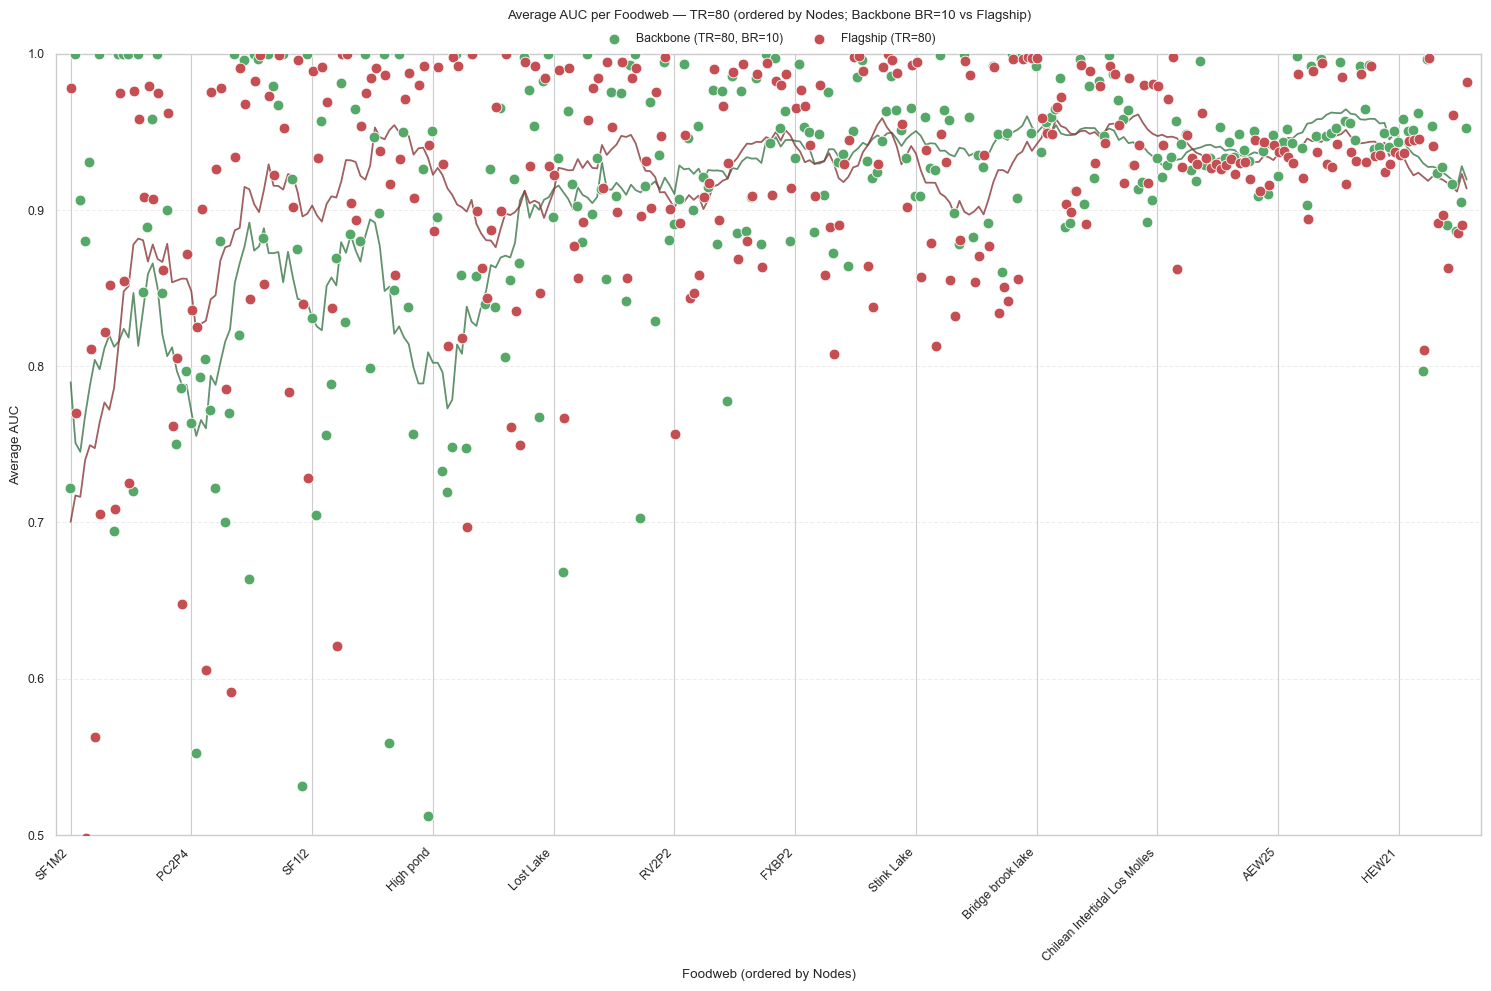

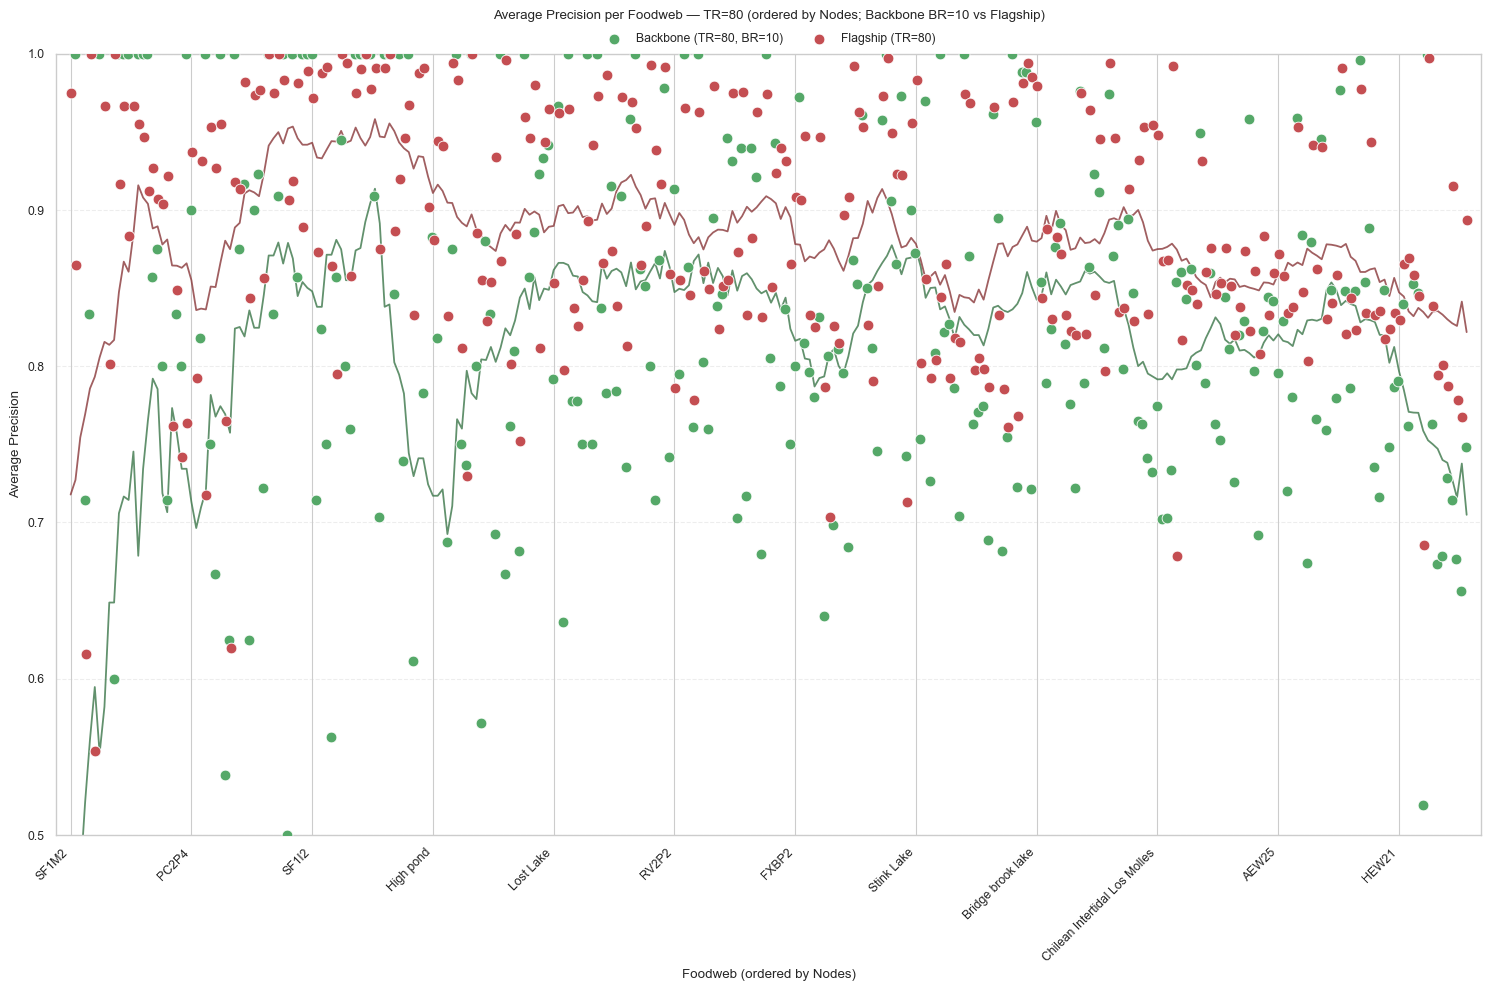

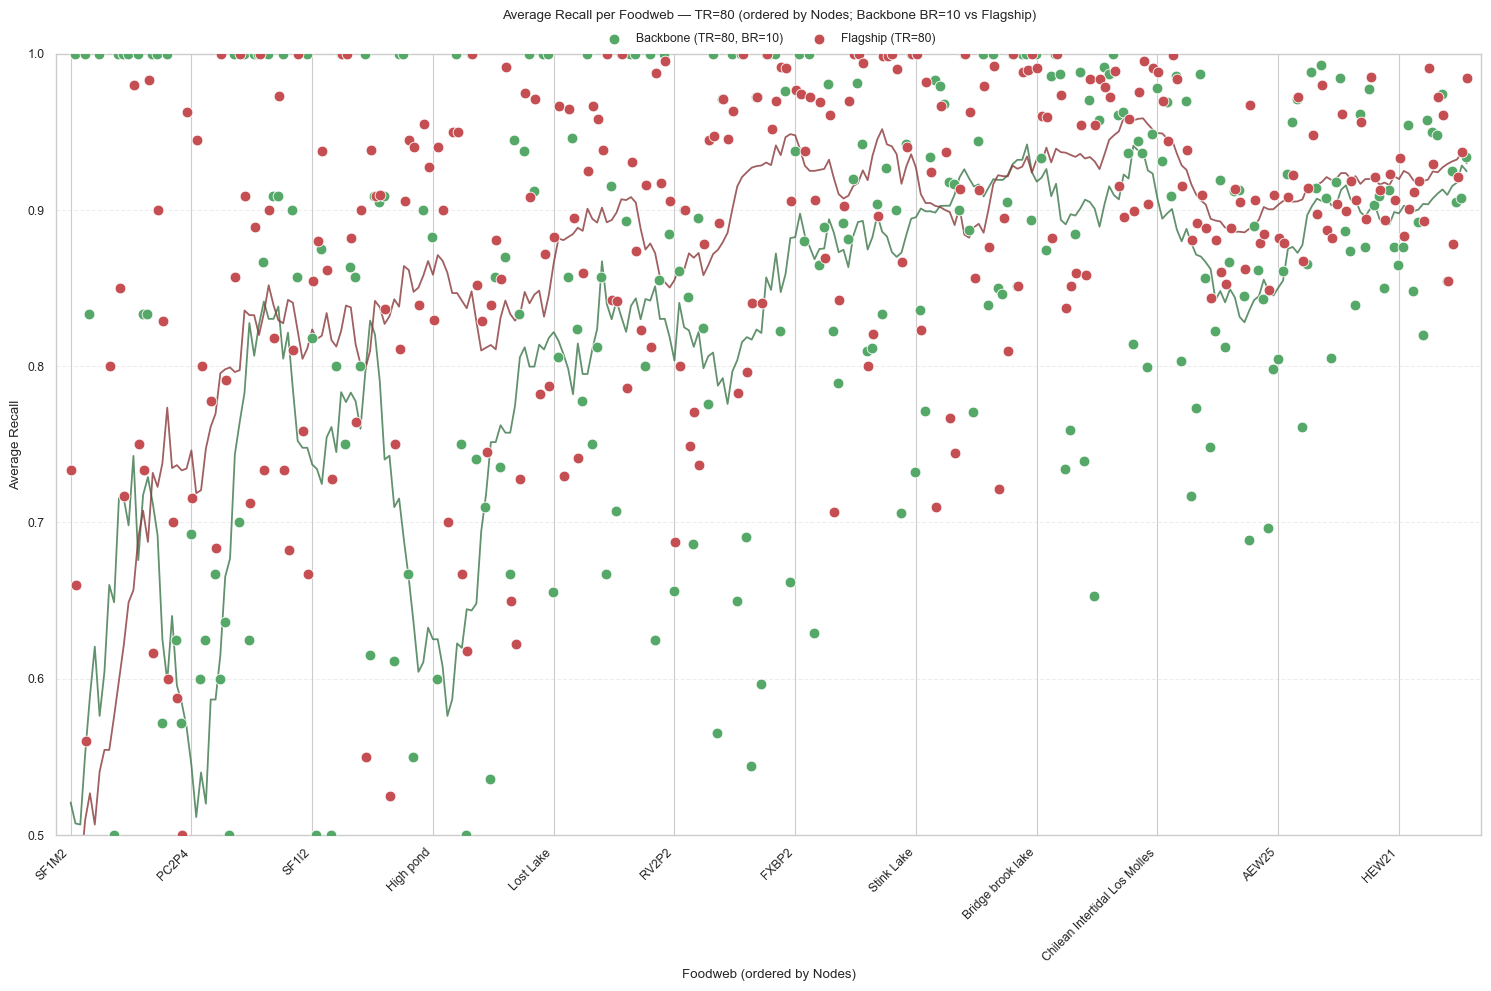

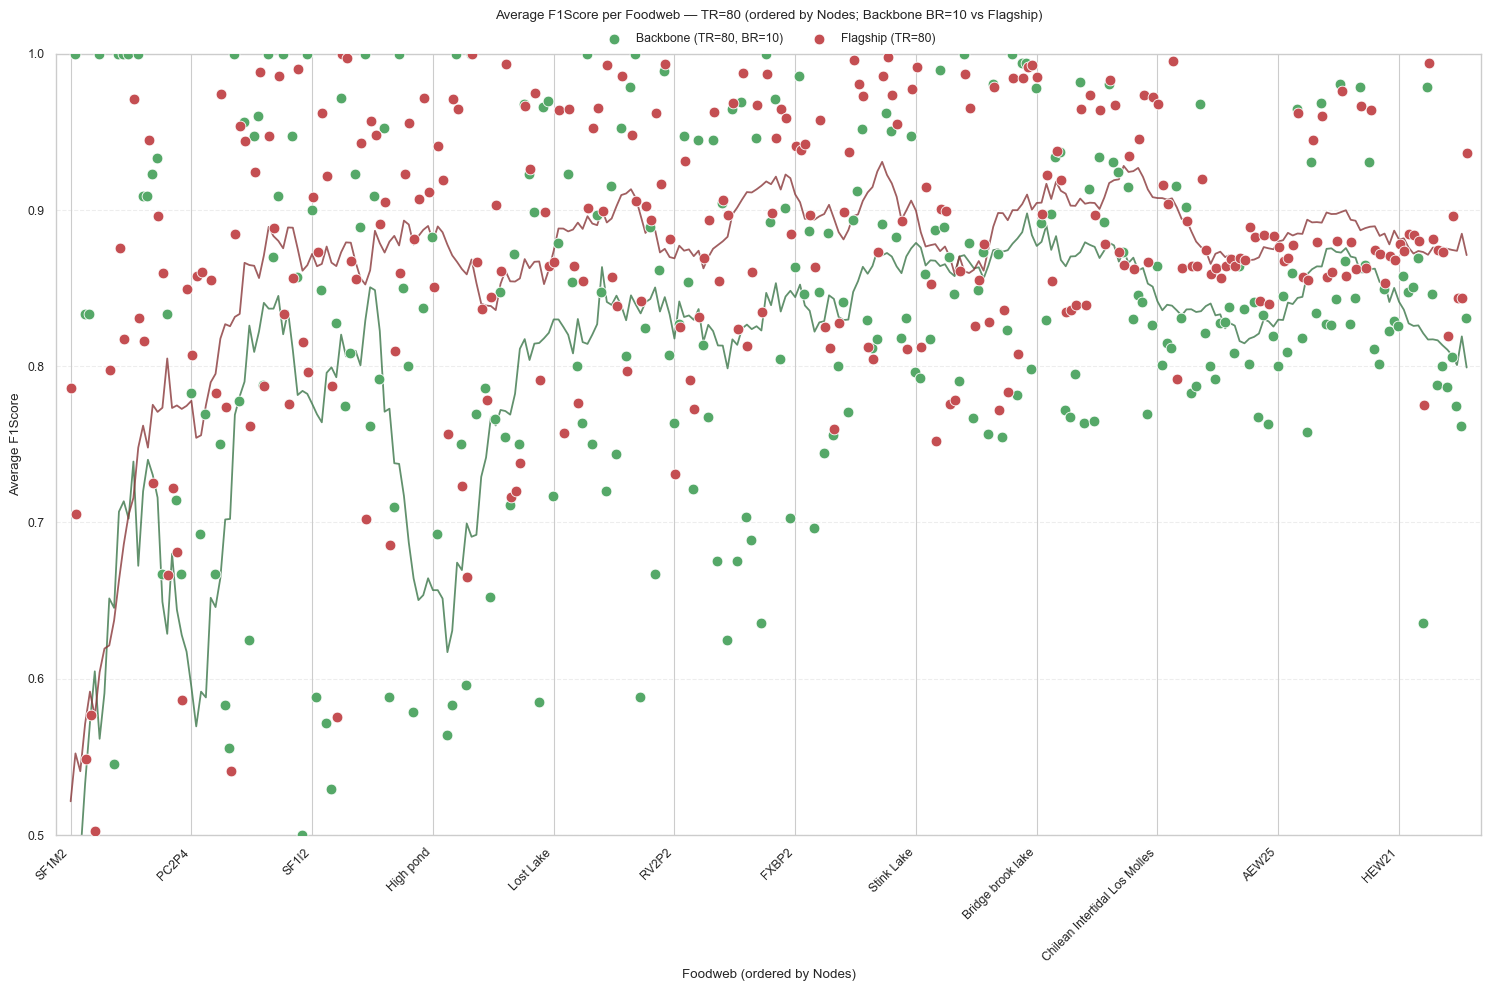

In [2]:
# %% AUC/Precision/Recall/F1Score average by foodweb (overlay two sources) — TR=80
import os, glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors  # ← for darkening colors

RESULTS_DIR_BACKBONE = "../../src/matlab/data/result_sweep_trainRatio_60-80_backboneRatio_10-90/prediction_scores_logs"
RESULTS_DIR_FLAGSHIP = "../../src/matlab/data/result_sweep_train_ratios_290/prediction_scores_logs"
ECOSYSTEM_META_CSV = "../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
GLOB_PATTERNS = ["*_results_random.csv", "*_results_*.csv", "*_result_*.csv"]

TRAIN_RATIO_TARGET = 80
BACKBONE_RATIO_TARGET = 10  # only for the BACKBONE series

sns.set_theme(style="whitegrid", context="paper")

def derive_foodweb_from_filename(path: str) -> str:
    base = os.path.basename(path)
    name, _ = os.path.splitext(base)
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join([p for p in name.split("_") if p])

def sanitize_fw(name: str) -> str:
    n = os.path.splitext(os.path.basename(str(name)))[0]
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        n = n.replace(token, "_")
    n = "_".join([p for p in n.split("_") if p])
    return n.lower()

def pick_col(cols, candidates):
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    raise KeyError(f"None of {candidates} found among: {list(cols)}")

def load_metric_means(results_dir, tr_target, br_target=None):
    files = []
    for pat in GLOB_PATTERNS:
        files.extend(glob.glob(os.path.join(results_dir, pat)))
    files = sorted(set(files))

    rows = []
    for path in files:
        try:
            df = pd.read_csv(path)
        except Exception:
            continue

        try:
            metric_col = pick_col(df.columns, [METRIC])
        except KeyError:
            continue

        bb  = next((c for c in ["BackboneRatio","Backbone_Ratio","Backbone","b_ratio"] if c in df.columns), None)
        tr  = next((c for c in ["TrainRatio","Train_Ratio","train_ratio"] if c in df.columns), None)
        if tr is None:
            continue

        df[metric_col] = pd.to_numeric(df[metric_col], errors="coerce")
        df[tr]  = pd.to_numeric(df[tr], errors="coerce")
        if bb is not None:
            df[bb] = pd.to_numeric(df[bb], errors="coerce")

        df["_TR"] = (df[tr]*100).round().astype(int) if df[tr].dropna().between(0,1).all() else df[tr].round().astype(int)

        if br_target is not None:
            if bb is None:
                continue
            df["_BR"] = (df[bb]*100).round().astype(int) if df[bb].dropna().between(0,1).all() else df[bb].round().astype(int)
            dff = df[(df["_TR"] == tr_target) & (df["_BR"] == br_target)].copy()
        else:
            dff = df[(df["_TR"] == tr_target)].copy()

        if dff.empty:
            continue

        rows.append({"Foodweb": derive_foodweb_from_filename(path), f"{METRIC}_mean": dff[metric_col].mean(skipna=True)})

    return pd.DataFrame(rows)

def darken(color, amount=0.7):
    r, g, b = mcolors.to_rgb(color)
    return tuple((amount*np.array([r, g, b])).clip(0, 1))

# === Loop over all metrics with identical plotting logic ===
for METRIC in ["AUC", "Precision", "Recall", "F1Score"]:
    # Load both series for this METRIC
    df_backbone = load_metric_means(RESULTS_DIR_BACKBONE, TRAIN_RATIO_TARGET, BACKBONE_RATIO_TARGET)
    df_flagship = load_metric_means(RESULTS_DIR_FLAGSHIP, TRAIN_RATIO_TARGET, br_target=None)

    if df_backbone.empty and df_flagship.empty:
        print(f"[Info] No matching rows for metric {METRIC}. Skipping.")
        continue

    # Merge, keep all foodwebs from both
    merged = pd.merge(
        df_backbone.rename(columns={f"{METRIC}_mean":f"{METRIC}_backbone"}),
        df_flagship.rename(columns={f"{METRIC}_mean":f"{METRIC}_flagship"}),
        on="Foodweb", how="outer"
    )

    # Load metadata and sort by Nodes (ascending)
    meta = pd.read_csv(ECOSYSTEM_META_CSV)
    fw_col    = pick_col(meta.columns, ["Foodweb","FoodWeb","foodweb","Network"])
    nodes_col = pick_col(meta.columns, ["Nodes","N","NumNodes","num_nodes","#Nodes","S"])

    meta2 = meta[[fw_col, nodes_col]].rename(columns={fw_col:"Foodweb_meta", nodes_col:"Nodes"}).copy()
    meta2["Foodweb_key"] = meta2["Foodweb_meta"].astype(str).map(sanitize_fw)

    merged["Foodweb_key"] = merged["Foodweb"].astype(str).map(sanitize_fw)
    merged = merged.merge(meta2[["Foodweb_key","Nodes"]], on="Foodweb_key", how="left")
    merged["Nodes_num"] = pd.to_numeric(merged["Nodes"], errors="coerce")

    if merged["Nodes_num"].notna().any():
        merged = merged.sort_values("Nodes_num", ascending=True).reset_index(drop=True)
    else:
        sort_val = merged.get(f"{METRIC}_flagship", pd.Series(index=merged.index)).fillna(
            merged.get(f"{METRIC}_backbone", pd.Series(index=merged.index))
        )
        merged = merged.assign(_sort=sort_val).sort_values("_sort", ascending=True).drop(columns=["_sort"]).reset_index(drop=True)

    # Plotting positions and thinned labels
    x = np.arange(len(merged))
    labels = merged["Foodweb"].tolist()
    step = max(1, int(np.ceil(len(labels) / 12)))
    tick_idx = list(range(0, len(labels), step))

    plt.figure(figsize=(15, 10))
    ax = plt.gca()

    # Scatter series (points)
    ax.scatter(x - 0.12, merged.get(f"{METRIC}_backbone"), s=60,
               label=f"Backbone (TR=80, BR={BACKBONE_RATIO_TARGET})",
               color="C2", edgecolors="white", linewidths=0.6, zorder=3)
    ax.scatter(x + 0.12, merged.get(f"{METRIC}_flagship"), s=60,
               label="Flagship (TR=80)",
               color="C3", edgecolors="white", linewidths=0.6, zorder=3)

    # Trend lines (slightly darker than points)
    window = max(5, int(np.ceil(len(merged) * 0.05)))
    trend_backbone = darken("C2", amount=0.7)
    trend_flagship = darken("C3", amount=0.7)

    y_b = merged.get(f"{METRIC}_backbone").to_numpy(dtype=float)
    mask_b = ~np.isnan(y_b)
    if mask_b.any():
        yb_smooth = pd.Series(y_b[mask_b]).rolling(window=window, center=True, min_periods=1).mean().to_numpy()
        ax.plot(x[mask_b], yb_smooth, color=trend_backbone, alpha=0.8, linewidth=1.3, zorder=2)

    y_f = merged.get(f"{METRIC}_flagship").to_numpy(dtype=float)
    mask_f = ~np.isnan(y_f)
    if mask_f.any():
        yf_smooth = pd.Series(y_f[mask_f]).rolling(window=window, center=True, min_periods=1).mean().to_numpy()
        ax.plot(x[mask_f], yf_smooth, color=trend_flagship, alpha=0.8, linewidth=1.3, zorder=2)

    # Axes & grid
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([labels[i] for i in tick_idx], rotation=45, ha="right")
    ax.set_ylim(0.5, 1.0)  # keep same logic/scale
    ax.set_xlabel("Foodweb (ordered by Nodes)")
    ax.set_ylabel(f"Average {METRIC}")
    ax.set_title(
        f"Average {METRIC} per Foodweb — TR=80 (ordered by Nodes; Backbone BR={BACKBONE_RATIO_TARGET} vs Flagship)",
        pad=25
    )
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    ax.margins(x=0.01)

    # Legend centered above
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=2, frameon=False)

    plt.tight_layout()
    plt.show()